<a href="https://colab.research.google.com/github/rix031110/Projects/blob/main/2.TGTG_Business_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
file_path= '/content/drive/MyDrive/Università/DATA SCIENCE FOR MANAGEMENT UNICATT/Analytical Base Table.xlsx'
df= pd.read_excel(file_path, header=0)

df.head(5)

,IPAddress,RecordedDate,Q1,Q2,Q3_1,Q3_2,Q3_3,Q3_4,Q3_5,Q3_6,...,Q22_6,Q22_7,Q22_8,Q23,Gender,Q25,Q26,Q27,Q28,Q29
0,93.34.233.131,2023-03-09 13:59:28,1,1,NaN,NaN,1.0,NaN,NaN,NaN,...,3,4,2,51,2,1,3,4,5,2.0
1,79.54.98.108,2023-03-09 15:44:57,1,1,NaN,NaN,1.0,NaN,NaN,1.0,...,5,5,5,60,2,1,3,4,3,4.0
2,93.47.231.10,2023-03-27 07:26:22,1,1,1.0,1.0,1.0,1.0,NaN,1.0,...,1,1,1,57,2,1,3,4,4,2.0
3,93.70.21.70,2023-03-27 18:10:44,1,1,1.0,1.0,NaN,NaN,NaN,NaN,...,1,1,1,22,2,1,1,3,3,5.0
4,95.74.34.99,2023-04-04 12:27:45,1,1,1.0,NaN,NaN,NaN,1.0,NaN,...,9,7,6,30,2,1,3,5,2,5.0


# Data Cleaning

## Keeping Only the Useful Variables

In [4]:
used_columns = [
    'Q1', 'Q2', 'Q3_1', 'Q3_2', 'Q3_3', 'Q3_4',
       'Q3_5', 'Q3_6', 'Q3_7', 'Q4_1', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9_1', 'Q9_2',
       'Q9_3', 'Q9_4', 'Q9_5', 'Q9_6', 'Q9_7', 'Q9_8', 'Q10', 'Q11_1', 'Q12_1',
       'Q12_2', 'Q12_3', 'Q12_4', 'Q12_5', 'Q13', 'Q14', 'Q15', 'Q16_1',
       'Q16_2', 'Q16_3', 'Q16_4', 'Q16_5', 'Q16_6', 'Q16_7', 'Q16_8', 'Q17_1',
       'Q17_2', 'Q17_3', 'Q17_4', 'Q17_5', 'Q17_6', 'Q17_7', 'Q18', 'Q19',
       'Q20', 'Q21', 'Q22_1', 'Q22_2', 'Q22_3', 'Q22_4', 'Q22_5', 'Q22_6',
       'Q22_7', 'Q22_8', 'Q23', 'Gender', 'Q25', 'Q26', 'Q27', 'Q28', 'Q29'

]

used_columns = [col for col in used_columns if col in df.columns]


df1 = df[used_columns]
df=df1.rename(columns={'Gender':'Q24'})
df.head()


,Q1,Q2,Q3_1,Q3_2,Q3_3,Q3_4,Q3_5,Q3_6,Q3_7,Q4_1,...,Q22_6,Q22_7,Q22_8,Q23,Q24,Q25,Q26,Q27,Q28,Q29
0,1,1,NaN,NaN,1.0,NaN,NaN,NaN,1.0,6,...,3,4,2,51,2,1,3,4,5,2.0
1,1,1,NaN,NaN,1.0,NaN,NaN,1.0,NaN,8,...,5,5,5,60,2,1,3,4,3,4.0
2,1,1,1.0,1.0,1.0,1.0,NaN,1.0,NaN,10,...,1,1,1,57,2,1,3,4,4,2.0
3,1,1,1.0,1.0,NaN,NaN,NaN,NaN,NaN,8,...,1,1,1,22,2,1,1,3,3,5.0
4,1,1,1.0,NaN,NaN,NaN,1.0,NaN,NaN,6,...,9,7,6,30,2,1,3,5,2,5.0


## Cleaning the Null Values

In [5]:
print('===MISSING VALUES===')
pd.set_option('display.max_rows', None)
print(df.isnull().sum())
pd.reset_option('display.max_rows')

===MISSING VALUES===
Q1         0
Q2         0
Q3_1      96
Q3_2     164
Q3_3      91
Q3_4     237
Q3_5     187
Q3_6     186
Q3_7     280
Q4_1       0
Q5         0
Q6         0
Q7         0
Q8         0
Q9_1       0
Q9_2       0
Q9_3       0
Q9_4       0
Q9_5       0
Q9_6       0
Q9_7       0
Q9_8       0
Q10        0
Q11_1      0
Q12_1      0
Q12_2      0
Q12_3      0
Q12_4      0
Q12_5      0
Q13        0
Q14        0
Q15        0
Q16_1      0
Q16_2      0
Q16_3      0
Q16_4      0
Q16_5      0
Q16_6      0
Q16_7      0
Q16_8      0
Q17_1      0
Q17_2      0
Q17_3      0
Q17_4      0
Q17_5      0
Q17_6      0
Q17_7      0
Q18        0
Q19        0
Q20        0
Q21        0
Q22_1      0
Q22_2      0
Q22_3      0
Q22_4      0
Q22_5      0
Q22_6      0
Q22_7      0
Q22_8      0
Q23        0
Q24        0
Q25        0
Q26        0
Q27        0
Q28        0
Q29       49
dtype: int64


In [6]:
df[df.isnull().any(axis=1)]
df['Q3_1']=df['Q3_1'].fillna(0)
df['Q3_2']=df['Q3_2'].fillna(0)
df['Q3_3']=df['Q3_3'].fillna(0)
df['Q3_4']=df['Q3_4'].fillna(0)
df['Q3_5']=df['Q3_5'].fillna(0)
df['Q3_6']=df['Q3_6'].fillna(0)
df['Q3_7']=df['Q3_7'].fillna(0)
df['Q29']= df['Q29'].fillna(0)
df

,Q1,Q2,Q3_1,Q3_2,Q3_3,Q3_4,Q3_5,Q3_6,Q3_7,Q4_1,...,Q22_6,Q22_7,Q22_8,Q23,Q24,Q25,Q26,Q27,Q28,Q29
0,1,1,0.0,0.0,1.0,0.0,0.0,0.0,1.0,6,...,3,4,2,51,2,1,3,4,5,2.0
1,1,1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,8,...,5,5,5,60,2,1,3,4,3,4.0
2,1,1,1.0,1.0,1.0,1.0,0.0,1.0,0.0,10,...,1,1,1,57,2,1,3,4,4,2.0
3,1,1,1.0,1.0,0.0,0.0,0.0,0.0,0.0,8,...,1,1,1,22,2,1,1,3,3,5.0
4,1,1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,6,...,9,7,6,30,2,1,3,5,2,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
289,1,2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1,...,6,5,4,51,2,1,4,3,2,4.0
290,1,2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1,...,6,5,4,53,1,1,4,2,2,2.0
291,1,2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1,...,6,5,4,53,1,1,3,2,2,2.0
292,1,2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1,...,9,8,6,44,1,1,4,4,2,4.0


# Population vs Sample

In [7]:
demographics= df[['Q23', 'Q24','Q25','Q26','Q27','Q28','Q29']]
istat= pd.read_csv('/content/drive/MyDrive/Università/DATA SCIENCE FOR MANAGEMENT UNICATT/Popolazione residente (1).csv')
istat1=pd.read_csv('/content/drive/MyDrive/Università/DATA SCIENCE FOR MANAGEMENT UNICATT/Popolazione residente.csv')

## Gender

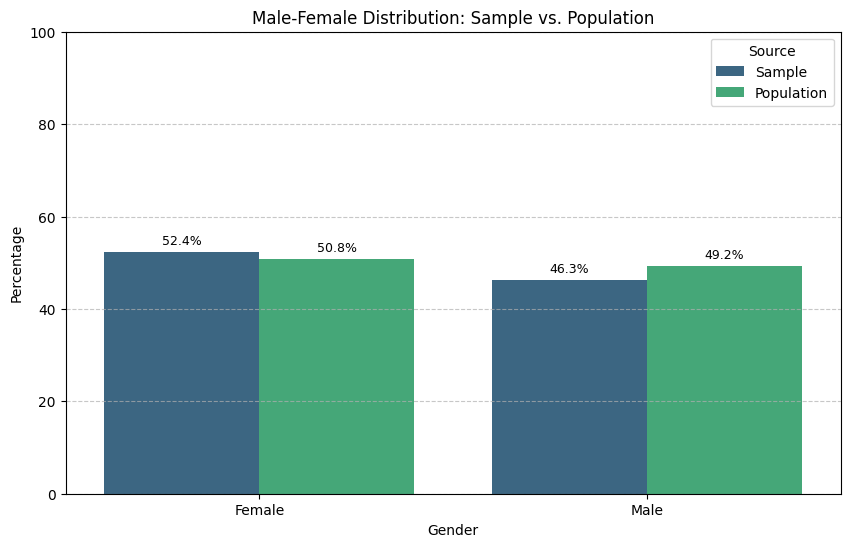

In [8]:
# 1. Demographics Gender Distribution (assuming 1=Male, 2=Female for Q24)
demographics_gender_counts = df['Q24'].value_counts(normalize=True) * 100
demographics_gender_df = pd.DataFrame(demographics_gender_counts).reset_index()
demographics_gender_df.columns = ['Gender_Code', 'Percentage']
demographics_gender_df['Gender'] = demographics_gender_df['Gender_Code'].map({1: 'Male', 2: 'Female'})
demographics_gender_df['Source'] = 'Sample'
demographics_gender_df = demographics_gender_df[['Source', 'Gender', 'Percentage']]

# 2. Population Gender Distribution (Istat combined)
# Assuming the last row (index 101) contains the totals for istat and istat1
total_istat_males = istat.loc[101, 'Totale maschi'] + istat1.loc[101, 'Totale maschi']
total_istat_females = istat.loc[101, 'Totale femmine'] + istat1.loc[101, 'Totale femmine']
total_istat_population = total_istat_males + total_istat_females

istat_male_percentage = (total_istat_males / total_istat_population) * 100
istat_female_percentage = (total_istat_females / total_istat_population) * 100

population_gender_data = {
    'Source': ['Population', 'Population'],
    'Gender': ['Male', 'Female'],
    'Percentage': [istat_male_percentage, istat_female_percentage]
}
population_gender_df = pd.DataFrame(population_gender_data)

# 3. Combine Data for Plotting
combined_gender_df = pd.concat([demographics_gender_df, population_gender_df], ignore_index=True)

# 4. Create Bar Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Gender', y='Percentage', hue='Source', data=combined_gender_df, palette='viridis')
plt.title('Male-Female Distribution: Sample vs. Population')
plt.xlabel('Gender')
plt.ylabel('Percentage')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add percentage labels on top of the bars
for container in plt.gca().containers:
    for patch in container.patches:
        height = patch.get_height()
        plt.gca().text(patch.get_x() + patch.get_width() / 2, height + 1, f'{height:.1f}%',
                       ha='center', va='bottom', color='black', fontsize=9)

plt.show()

## Age

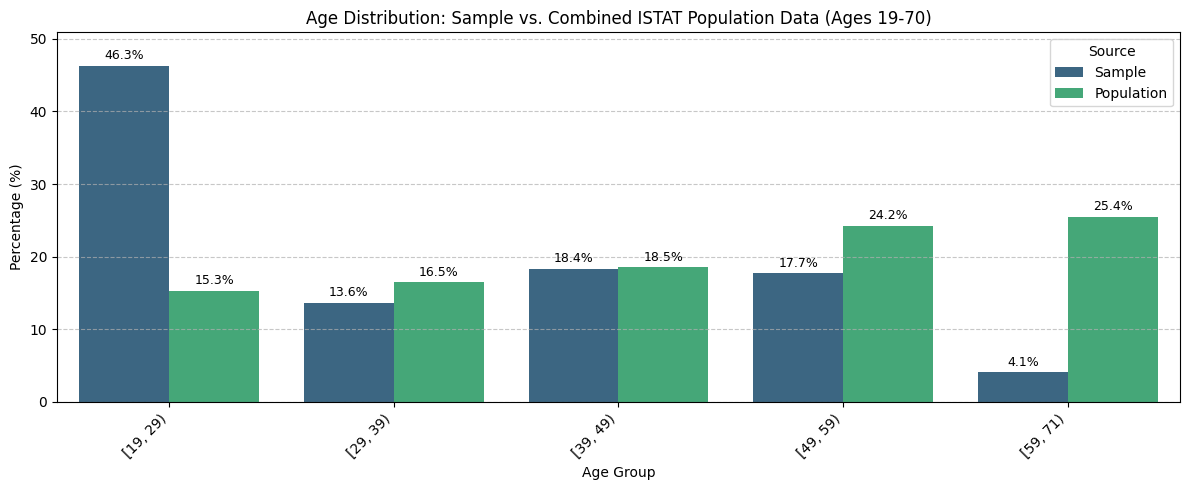

In [9]:
# Combine ISTAT data for total population per age
# Ensure 'Età' column is numeric and handle '100 e oltre' if present, though our bins go up to 70.
# For ages above 70 in ISTAT, they will be grouped into the last bin if it's open-ended or excluded if the bin ends at 70.
istat_combined_df = pd.concat([istat[['Età', 'Totale']], istat1[['Età', 'Totale']]], ignore_index=True)

# Filter out rows where 'Età' is 'Totale' before conversion
istat_combined_df = istat_combined_df[istat_combined_df['Età'] != 'Totale']
istat_combined_df['Età'] = istat_combined_df['Età'].replace('100 e oltre', 100).astype(int)
istat_combined_sum = istat_combined_df.groupby('Età')['Totale'].sum().reset_index()

# Define the bins as used previously for df['Q23'] (min_age=19, max_age=70)
min_age_survey = df['Q23'].min()
max_age_survey = df['Q23'].max()

# Ensure bins are consistent with previous analysis: [19, 29), [29, 39), ..., [59, 71)
bins_for_comparison = [19, 29, 39, 49, 59, max_age_survey + 1]

# --- 1. Sample Age Distribution ---
df_age_binned = pd.cut(df['Q23'], bins=bins_for_comparison, right=False, include_lowest=True)
sample_age_counts = df_age_binned.value_counts().sort_index()
sample_age_percentages = (sample_age_counts / len(df)) * 100
sample_df_for_plot = pd.DataFrame({
    'Age_Bin': sample_age_percentages.index.astype(str), # Convert interval to string for plotting
    'Percentage': sample_age_percentages.values,
    'Source': 'Sample'
})

# --- 2. Population Age Distribution (from ISTAT combined) ---
# Filter ISTAT data to ages within our comparison bins (19 to 70)
istat_filtered = istat_combined_sum[(istat_combined_sum['Età'] >= min_age_survey) & (istat_combined_sum['Età'] < max_age_survey + 1)]

# Bin ISTAT combined data using the same bins
# It's important to use the 'weights' parameter for histplot if you don't expand the DataFrame
# Or, group by binned age and sum 'Totale'
population_age_binned = pd.cut(istat_filtered['Età'], bins=bins_for_comparison, right=False, include_lowest=True)
population_age_counts_binned = istat_filtered.groupby(population_age_binned, observed=False)['Totale'].sum()
total_population_in_bins = population_age_counts_binned.sum()

population_age_percentages = (population_age_counts_binned / total_population_in_bins) * 100
population_df_for_plot = pd.DataFrame({
    'Age_Bin': population_age_percentages.index.astype(str),
    'Percentage': population_age_percentages.values,
    'Source': 'Population'
})

# --- 3. Combine Data for Plotting ---
final_plot_df = pd.concat([sample_df_for_plot, population_df_for_plot])

# --- 4. Plotting ---
plt.figure(figsize=(12, 5))
sns.barplot(x='Age_Bin', y='Percentage', hue='Source', data=final_plot_df, palette='viridis')
plt.title('Age Distribution: Sample vs. Combined ISTAT Population Data (Ages 19-70)')
plt.xlabel('Age Group')
plt.ylabel('Percentage (%)')
plt.ylim(0, final_plot_df['Percentage'].max() * 1.1) # Add a bit of space above max bar
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add percentage labels on top of the bars
for container in plt.gca().containers:
    for patch in container.patches:
        height = patch.get_height()
        if height > 0:
            plt.gca().text(patch.get_x() + patch.get_width() / 2, height + 0.5, f'{height:.1f}%',
                           ha='center', va='bottom', color='black', fontsize=9)
plt.tight_layout()
plt.show()

## Education Level

In [10]:
education= pd.read_csv('/content/drive/MyDrive/Università/DATA SCIENCE FOR MANAGEMENT UNICATT/Popolazione per titolo di studio e regioni (IT1,52_1194_DF_DCCV_POPTIT1_UNT2020_2,1.0).csv')

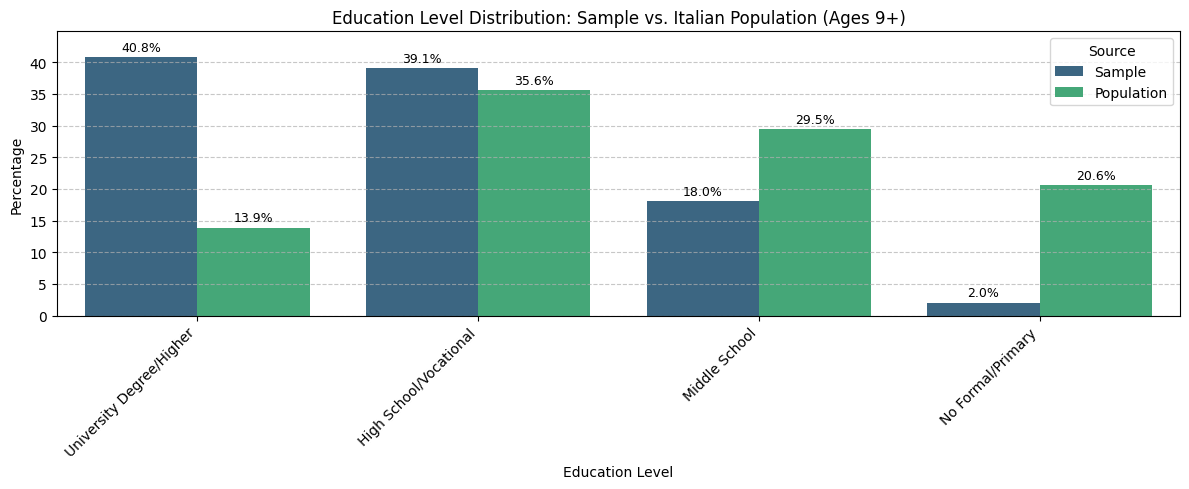

In [11]:
# Define mapping for Q27
q27_mapping = {
    1: 'No Formal/Primary',
    2: 'Middle School',
    3: 'High School/Vocational',
    4: 'Bachelor\'s',
    5: 'Master\'s',
    6: 'PhD/Other'
}
df['Education_Level'] = df['Q27'].map(q27_mapping)

# Consolidate higher education for sample to match population grouping
def consolidate_higher_education(level):
    if level in ['Bachelor\'s', 'Master\'s', 'PhD/Other']:
        return 'University Degree/Higher'
    return level

df['Education_Level_Grouped'] = df['Education_Level'].apply(consolidate_higher_education)

# Calculate sample education percentages with grouped categories
sample_education_counts_grouped = df['Education_Level_Grouped'].value_counts(normalize=True) * 100
sample_education_df = sample_education_counts_grouped.reset_index()
sample_education_df.columns = ['Education_Level', 'Percentage']
sample_education_df['Source'] = 'Sample'

# --- Use the provided population percentages directly ---
# From the context: "9 anni e più il 35,6% ha un diploma di scuola secondaria di secondo grado o di qualifica professionale,
# il 29,5% la licenza di scuola media, il 16% la licenza di scuola elementare.
# I laureati e le persone che hanno conseguito un diploma di Alta Formazione Artistica, Musicale e Coreutica sono il 13,9%
# mentre analfabeti e alfabeti senza titolo di studio raggiungono il 4,6%."

population_data_manual = [
    {'Education_Level': 'High School/Vocational', 'Percentage': 35.6},
    {'Education_Level': 'Middle School', 'Percentage': 29.5},
    {'Education_Level': 'No Formal/Primary', 'Percentage': 16.0 + 4.6}, # Combining 'licenza di scuola elementare' and 'analfabeti e alfabeti senza titolo di studio'
    {'Education_Level': 'University Degree/Higher', 'Percentage': 13.9} # Laureati e Alta Formazione
]
population_education_df = pd.DataFrame(population_data_manual)
population_education_df['Source'] = 'Population'

# --- Combine and Plot ---
combined_education_df = pd.concat([sample_education_df, population_education_df])

plt.figure(figsize=(12, 5))
sns.barplot(x='Education_Level', y='Percentage', hue='Source', data=combined_education_df, palette='viridis')
plt.title('Education Level Distribution: Sample vs. Italian Population (Ages 9+)')
plt.xlabel('Education Level')
plt.ylabel('Percentage')
plt.ylim(0, combined_education_df['Percentage'].max() * 1.1) # Add a bit of space above max bar
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add percentage labels on top of the bars
for container in plt.gca().containers:
    for patch in container.patches:
        height = patch.get_height()
        if height > 0:
            plt.gca().text(patch.get_x() + patch.get_width() / 2, height + 0.5, f'{height:.1f}%',
                           ha='center', va='bottom', color='black', fontsize=9)

plt.tight_layout()
plt.show()

## How Many People Live With You?

In [12]:
# Map Q28 values to actual number of people based on user's clarification
def map_q28_to_actual_people(q28_value):
    if q28_value == 7:
        return '6 or more'
    else:
        return str(q28_value - 1) # label - 1

df['Actual_Num_People'] = df['Q28'].apply(map_q28_to_actual_people)

# Calculate frequency and percentage for the new 'Actual_Num_People' column
actual_number_of_people = df['Actual_Num_People'].value_counts(normalize=True).reset_index()
actual_number_of_people.columns = ['Actual_Num_People', 'Percentage']
actual_number_of_people['Percentage'] = (actual_number_of_people['Percentage'] * 100).map(lambda x: f'{x:.2f}%')

# Ensure correct order for plotting (0, 1, 2, 3, 4, 5, 6 or more)
custom_order = ['0', '1', '2', '3', '4', '5', '6 or more']
actual_number_of_people['Actual_Num_People'] = pd.Categorical(
    actual_number_of_people['Actual_Num_People'],
    categories=custom_order,
    ordered=True
)
actual_number_of_people = actual_number_of_people.sort_values('Actual_Num_People')

# Convert percentages to numeric for plotting bar heights
actual_number_of_people['Numeric_Percentage'] = actual_number_of_people['Percentage'].str.rstrip('%').astype(float)

display(actual_number_of_people)

,Actual_Num_People,Percentage,Numeric_Percentage
2,0,16.67%,16.67
0,1,37.07%,37.07
1,2,23.47%,23.47
3,3,15.31%,15.31
4,4,5.78%,5.78
6,5,0.68%,0.68
5,6 or more,1.02%,1.02


/tmp/ipykernel_7036/303664018.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


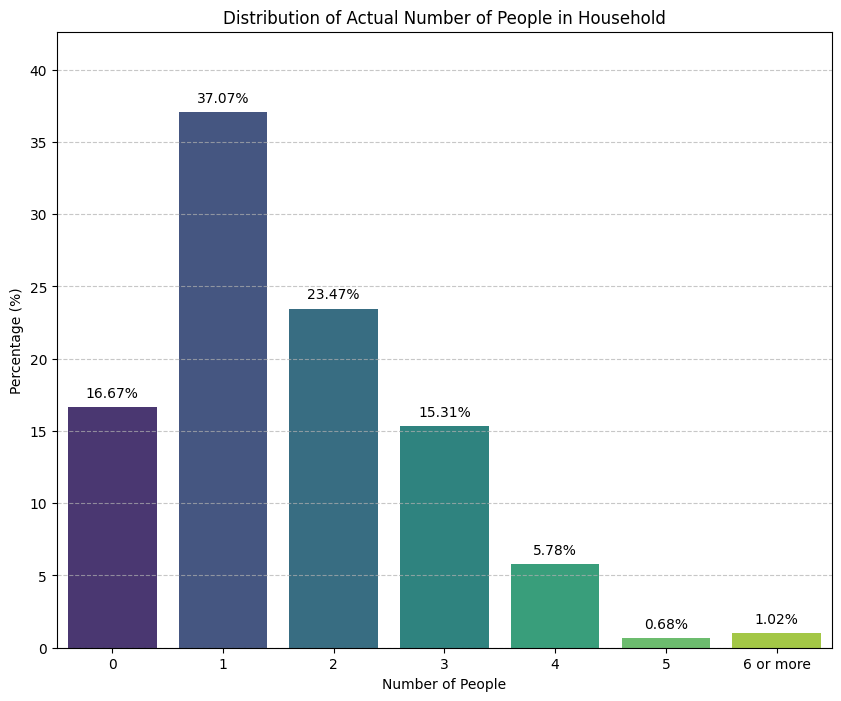

In [13]:
plt.figure(figsize=(10, 8))
ax = sns.barplot(
    x='Actual_Num_People',
    y='Numeric_Percentage',
    data=actual_number_of_people,
    palette='viridis'
)

plt.title('Distribution of Actual Number of People in Household')
plt.xlabel('Number of People')
plt.ylabel('Percentage (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add percentage labels on top of the bars
for p in ax.patches:
    percentage_value = f'{p.get_height():.2f}%'
    ax.annotate(percentage_value,
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 10), textcoords='offset points')

plt.ylim(0, actual_number_of_people['Numeric_Percentage'].max() * 1.15) # Adjust y-limit for labels
plt.show()

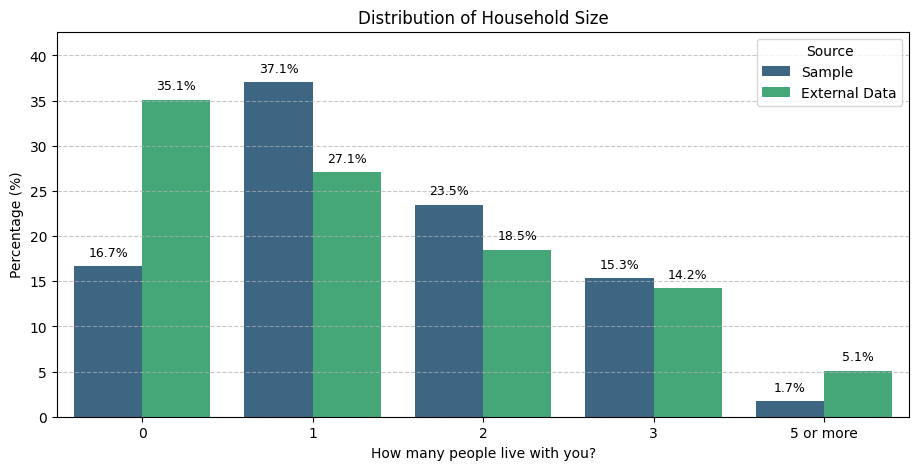

In [79]:
# 1. Prepare Sample Data (using actual_number_of_people from previous steps)
sample_df_prepared = actual_number_of_people.copy()
sample_df_prepared = sample_df_prepared.rename(columns={'Actual_Num_People': 'Number_of_People', 'Numeric_Percentage': 'Percentage_Value'})

# Consolidate '5' and '6 or more' into '5 or more' for sample data
merged_sample_percentage = sample_df_prepared[sample_df_prepared['Number_of_People'].isin(['5', '6 or more'])]['Percentage_Value'].sum()
merged_sample_row = pd.DataFrame([{'Number_of_People': '5 or more', 'Percentage_Value': merged_sample_percentage}])
sample_comparison_df_new = pd.concat([
    sample_df_prepared[~sample_df_prepared['Number_of_People'].isin(['5', '6 or more'])],
    merged_sample_row
], ignore_index=True)
sample_comparison_df_new['Source'] = 'Sample'
sample_comparison_df_new = sample_comparison_df_new[['Number_of_People', 'Percentage_Value', 'Source']]

# 2. Prepare External Data
external_data_raw_new = {
    'Number_of_People_Text': ['1 component (Single)', '2 components', '3 components', '4 components', '5 components', '6 or more components (Large families)'],
    'Percentage_Value': [35.1, 27.1, 18.5, 14.2, 3.7, 1.4]
}
external_df_raw = pd.DataFrame(external_data_raw_new)

# Define the mapping function for external data to apply the 'label-1' logic *before* merging
def map_external_text_to_unmerged_actual_people(text_label):
    if '6 or more' in text_label:
        return '6 or more' # Temporarily keep '6 or more' as a distinct category
    else:
        num_str = text_label.split(' ')[0]
        try:
            num = int(num_str)
            return str(num - 1)
        except ValueError:
            return 'Unknown'

external_df_temp = external_df_raw.copy()
external_df_temp['Number_of_People'] = external_df_temp['Number_of_People_Text'].apply(map_external_text_to_unmerged_actual_people)
external_df_temp['Source'] = 'External Data'

# Consolidate '4' (from '5 componenti') and '6 or more' (from '6 o più componenti') into '5 or more' for external data
merged_external_percentage = external_df_temp[external_df_temp['Number_of_People'].isin(['4', '6 or more'])]['Percentage_Value'].sum()
merged_external_row = pd.DataFrame([{'Number_of_People': '5 or more', 'Percentage_Value': merged_external_percentage, 'Source': 'External Data'}])
external_df_new = pd.concat([
    external_df_temp[~external_df_temp['Number_of_People'].isin(['4', '6 or more'])],
    merged_external_row
], ignore_index=True)
external_df_new = external_df_new[['Number_of_People', 'Percentage_Value', 'Source']] # Reorder columns

# Define explicit categories and order for the 'Number_of_People' column (after merging)
custom_categories_comparison = ['0', '1', '2', '3', '5 or more']
external_df_new['Number_of_People'] = pd.Categorical(external_df_new['Number_of_People'], categories=custom_categories_comparison, ordered=True)
sample_comparison_df_new['Number_of_People'] = pd.Categorical(sample_comparison_df_new['Number_of_People'], categories=custom_categories_comparison, ordered=True)

external_df_new = external_df_new.sort_values('Number_of_People')
sample_comparison_df_new = sample_comparison_df_new.sort_values('Number_of_People')

# 3. Combine DataFrames
combined_comparison_df_final = pd.concat([sample_comparison_df_new, external_df_new], ignore_index=True)

# 4. Create Grouped Bar Plot
plt.figure(figsize=(11, 5))
ax = sns.barplot(x='Number_of_People', y='Percentage_Value', hue='Source', data=combined_comparison_df_final, palette='viridis')

plt.title('Distribution of Household Size')
plt.xlabel('How many people live with you?')
plt.ylabel('Percentage (%)')
plt.ylim(0, combined_comparison_df_final['Percentage_Value'].max() * 1.15) # Add space for labels
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add percentage labels
for container in ax.containers:
    for patch in container.patches:
        height = patch.get_height()
        if height > 0:
            ax.annotate(f'{height:.1f}%',
                        (patch.get_x() + patch.get_width() / 2., height),
                        ha='center', va='bottom', fontsize=9, color='black',
                        xytext=(0, 5), textcoords='offset points') # Use annotate for xytext
plt.show()

# What Limits TGTG Use?

In [15]:
drivers_columns = ['Q15', 'Q16_1', 'Q16_2', 'Q16_3', 'Q16_4', 'Q16_5', 'Q16_6', 'Q16_7', 'Q16_8', 'Q20', 'Q21', 'Q22_1', 'Q22_2', 'Q22_3', 'Q22_4', 'Q22_5', 'Q22_6', 'Q22_7', 'Q22_8']
drivers = df[drivers_columns]

combination_columns = ['Q22_1', 'Q22_2', 'Q22_3', 'Q22_4', 'Q22_5', 'Q22_6', 'Q22_7', 'Q22_8']
combination = df[combination_columns]

negative_columns = ['Q16_1', 'Q16_2', 'Q16_3', 'Q16_4', 'Q16_5', 'Q16_6', 'Q16_7', 'Q16_8']
negative = df[negative_columns]

## Perceived Barriers

In [16]:
combined_q22_stats = pd.DataFrame({
    'Mean': df[combination_columns].mean().round(2),
    'Median': df[combination_columns].median().round(2),
    'Std': df[combination_columns].std().round(2)
})
display(combined_q22_stats)

print("The most liked ideal food waste management app appears to be: \n'Free app, with home delivery and possibility to choose the food in the Magic Box'")

,Mean,Median,Std
Q22_1,7.74,8.0,2.42
Q22_2,6.61,7.0,2.43
Q22_3,7.07,7.0,2.13
Q22_4,5.45,6.0,2.14
Q22_5,5.47,6.0,3.03
Q22_6,4.90,5.0,2.78
Q22_7,4.93,5.0,2.69
Q22_8,4.03,4.0,2.46


The most liked ideal food waste management app appears to be: 
'Free app, with home delivery and possibility to choose the food in the Magic Box'


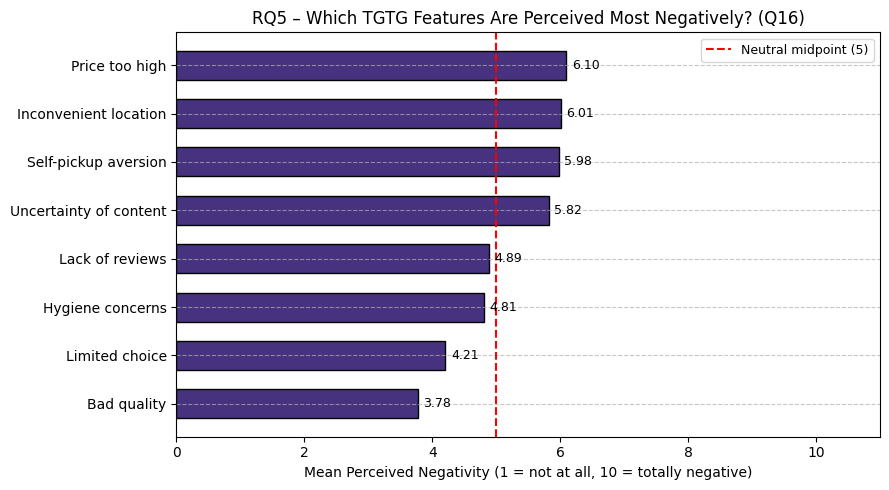

In [22]:
# Define q16_columns and q16_labels (assuming these were defined in a previous, un-executed cell)
q16_columns = ['Q16_1', 'Q16_2', 'Q16_3', 'Q16_4', 'Q16_5', 'Q16_6', 'Q16_7', 'Q16_8']
q16_labels = {
    'Q16_1': 'Price too high',
    'Q16_2': 'Self-pickup aversion',
    'Q16_3': 'Bad quality',
    'Q16_4': 'Limited choice',
    'Q16_5': 'Uncertainty of content',
    'Q16_6': 'Hygiene concerns',
    'Q16_7': 'Lack of reviews',
    'Q16_8': 'Inconvenient location'
}

means_q16 = df[q16_columns].mean().rename(q16_labels).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(means_q16.index, means_q16.values,
               color=sns.color_palette('viridis')[0], edgecolor='black', height=0.6) # Using a color from viridis palette
ax.bar_label(bars, fmt='%.2f', padding=4, fontsize=9)
ax.axvline(5, color='red', linestyle='--', linewidth=1.5, label='Neutral midpoint (5)')
ax.set_xlabel('Mean Perceived Negativity (1 = not at all, 10 = totally negative)')
ax.set_title('RQ5 – Which TGTG Features Are Perceived Most Negatively? (Q16)')
ax.set_xlim(0, 11)
ax.legend(fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.7) # Applying grid options
plt.tight_layout()
plt.show()

## App Dimension

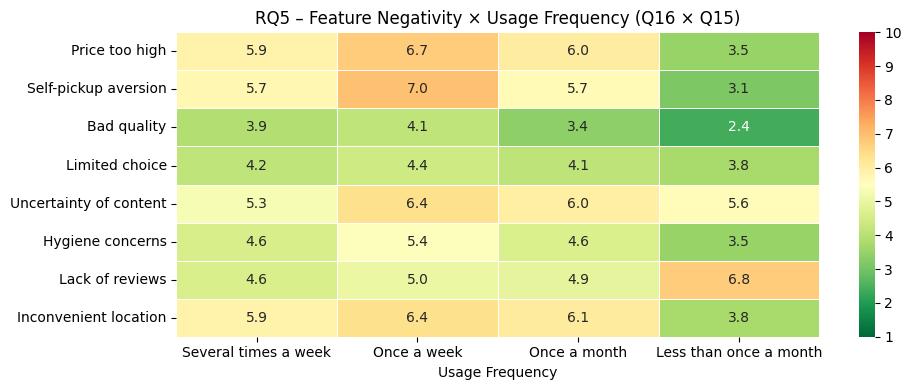

In [26]:
# Define q15_labels for Q15 (Usage Frequency)
q15_labels = {
    1: 'Several times a week',
    2: 'Once a week',
    3: 'Once a month',
    4: 'Less than once a month'
}

# Define the order of frequency for consistent plotting
freq_order = [
    'Several times a week',
    'Once a week',
    'Once a month',
    'Less than once a month'
]

# Ensure q16_columns is defined (it should be from cell 3P_Fxg-gCMJO)
q16_columns = ['Q16_1', 'Q16_2', 'Q16_3', 'Q16_4', 'Q16_5', 'Q16_6', 'Q16_7', 'Q16_8']
q16_labels = {
    'Q16_1': 'Price too high',
    'Q16_2': 'Self-pickup aversion',
    'Q16_3': 'Bad quality',
    'Q16_4': 'Limited choice',
    'Q16_5': 'Uncertainty of content',
    'Q16_6': 'Hygiene concerns',
    'Q16_7': 'Lack of reviews',
    'Q16_8': 'Inconvenient location'
}

df_q15 = df[df['Q15'].isin([1, 2, 3, 4])].copy()
df_q15['Q15_label'] = df_q15['Q15'].map(q15_labels)

group_means_q15 = (
    df_q15.groupby('Q15_label')[q16_columns]
    .mean()
    .reindex(freq_order)
    .rename(columns=q16_labels)
)

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    group_means_q15.T,
    annot=True, fmt='.1f',
    cmap='RdYlGn_r',
    linewidths=0.5,
    vmin=1, vmax=10,
    ax=ax
)
ax.set_title('RQ5 – Feature Negativity × Usage Frequency (Q16 × Q15)')
ax.set_xlabel('Usage Frequency')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

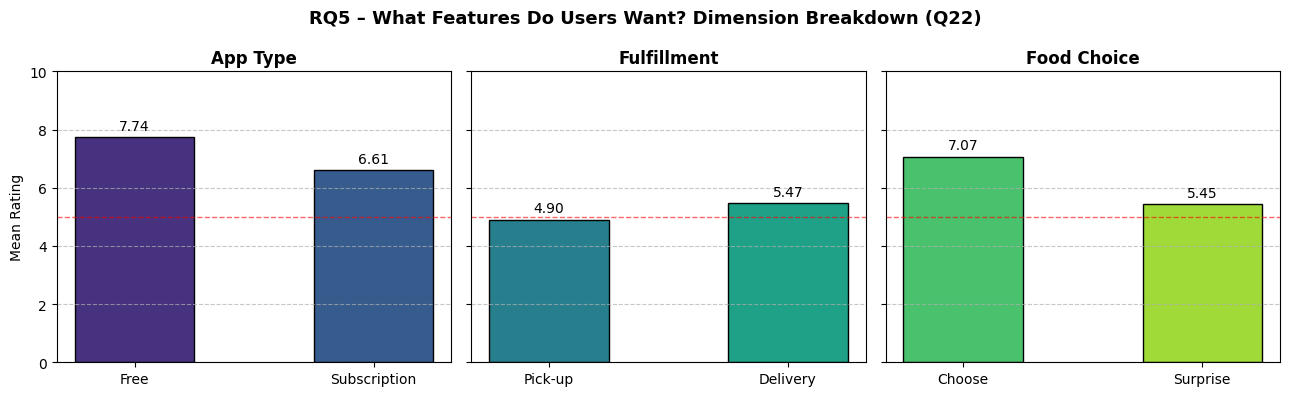

In [29]:
# Map Q22 columns to descriptive names for plotting
df_q22 = df.rename(columns={
    'Q22_1': 'Free',
    'Q22_2': 'Subscription',
    'Q22_3': 'Choose',
    'Q22_4': 'Surprise',
    'Q22_5': 'Delivery',
    'Q22_6': 'Pick_up'
})[['Free', 'Subscription', 'Choose', 'Surprise', 'Delivery', 'Pick_up']]

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

# Updated to use viridis palette and assigned to specific options
viridis_palette = sns.color_palette('viridis', n_colors=6) # Get 6 distinct colors from viridis
dim_pairs = [
    ('App Type',    ['Free', 'Subscription'], [viridis_palette[0], viridis_palette[1]]),
    ('Fulfillment',  ['Pick_up', 'Delivery'],  [viridis_palette[2], viridis_palette[3]]),
    ('Food Choice', ['Choose', 'Surprise'],   [viridis_palette[4], viridis_palette[5]]),
]

for ax, (title, options, colors) in zip(axes, dim_pairs):
    vals   = [df_q22[opt].mean() for opt in options]
    labels = [opt.replace('_', '-') for opt in options]
    bars   = ax.bar(labels, vals, color=colors, edgecolor='black', width=0.5)
    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=10)
    ax.axhline(5, color='red', linestyle='--', linewidth=1, alpha=0.6)
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, 10)
    ax.set_ylabel('Mean Rating' if ax == axes[0] else '')
    ax.grid(axis='y', linestyle='--', alpha=0.7) # Updated alpha to 0.7

fig.suptitle('RQ5 – What Features Do Users Want? Dimension Breakdown (Q22)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Drivers of Consumers Who Are Using Food Waste Apps

In [30]:
q12_columns = ['Q12_1', 'Q12_2', 'Q12_3', 'Q12_4', 'Q12_5']

# Determine the overall min and max score across all Q12 questions for consistent x-axis
overall_min_score = df[q12_columns].min().min()
overall_max_score = df[q12_columns].max().max()

In [31]:
q12_columns = ['Q12_1', 'Q12_2', 'Q12_3', 'Q12_4', 'Q12_5']
combined_q12_stats = pd.DataFrame({
    'Mean': df[q12_columns].mean().round(2),
    'Median': df[q12_columns].median().round(2),
    'Std': df[q12_columns].std().round(2)
})
display(combined_q12_stats)

,Mean,Median,Std
Q12_1,3.58,3.0,2.14
Q12_2,3.84,3.0,2.47
Q12_3,4.04,4.0,2.30
Q12_4,3.59,3.0,2.51
Q12_5,7.49,8.0,2.37


## Reasons to use TGTG

,Value,Frequency,Percentage
0,1,81,27.55%
1,2,76,25.85%
2,3,53,18.03%
3,4,37,12.59%
4,5,36,12.24%
5,6,11,3.74%


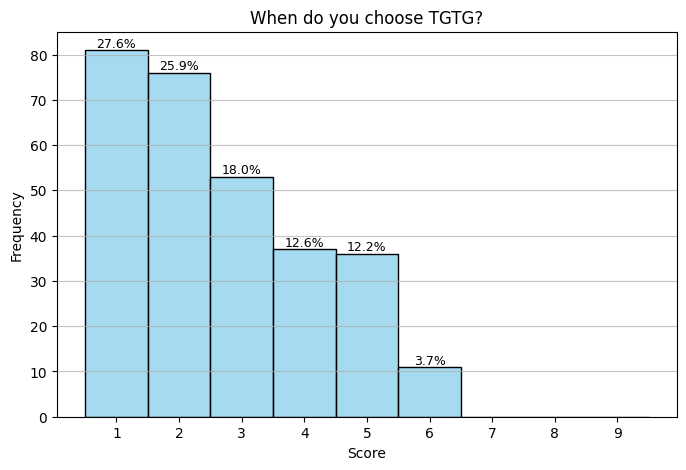

More than 50% of the sample choose TGTG when: 
- do not know what to eat 
- notice a Magix Box available nearby


In [80]:
q20_frequency_table = df['Q20'].value_counts().reset_index()
q20_frequency_table.columns = ['Value', 'Frequency']
q20_frequency_table['Percentage'] = (q20_frequency_table['Frequency'] / len(df)) * 100
q20_frequency_table['Percentage'] = q20_frequency_table['Percentage'].map(lambda x: f'{x:.2f}%')

display(q20_frequency_table.sort_values(by='Value').reset_index(drop=True))
col = 'Q20'
plt.figure(figsize=(8, 5))
ax = sns.histplot(df[col], bins=np.arange(overall_min_score, overall_max_score + 2) - 0.5, kde=False, color='skyblue', edgecolor='black', stat='count')
plt.title(f'When do you choose TGTG?')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.xticks(range(int(overall_min_score), int(overall_max_score) + 1))
plt.grid(axis='y', alpha=0.75)


for patch in ax.patches:
    x = patch.get_x() + patch.get_width() / 2
    count = patch.get_height()
    total_count = len(df[col])
    percentage = (count / total_count) * 100
    if count > 0:
        ax.text(x, count, f'{percentage:.1f}%', ha='center', va='bottom', fontsize=9, color='black')

plt.show()

print('More than 50% of the sample choose TGTG when: \n- do not know what to eat \n- notice a Magix Box available nearby')

## What are the attitudes of consumers toward food waste in Italian homes?

### Mean, Median and Standard Deviation Values for Q12 Questions

In [33]:
q12_columns = ['Q12_1', 'Q12_2', 'Q12_3', 'Q12_4', 'Q12_5']
combined_q12_stats = pd.DataFrame({
    'Mean': df[q12_columns].mean().round(2),
    'Median': df[q12_columns].median().round(2),
    'Std': df[q12_columns].std().round(2)
})
display(combined_q12_stats)

,Mean,Median,Std
Q12_1,3.58,3.0,2.14
Q12_2,3.84,3.0,2.47
Q12_3,4.04,4.0,2.30
Q12_4,3.59,3.0,2.51
Q12_5,7.49,8.0,2.37


### Individual Histogram Plots for Q12 Questions

In [34]:
q12_columns = ['Q12_1', 'Q12_2', 'Q12_3', 'Q12_4', 'Q12_5']

# Determine the overall min and max score across all Q12 questions for consistent x-axis
overall_min_score = df[q12_columns].min().min()
overall_max_score = df[q12_columns].max().max()

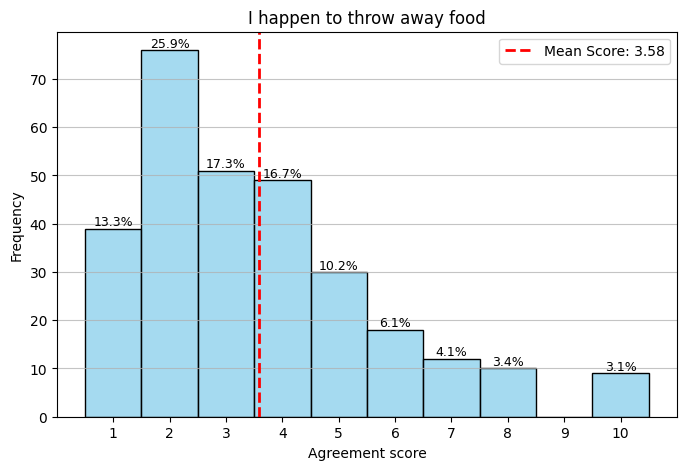

In [35]:
col = 'Q12_1'
plt.figure(figsize=(8, 5))
ax = sns.histplot(df[col], bins=np.arange(overall_min_score, overall_max_score + 2) - 0.5, kde=False, color='skyblue', edgecolor='black', stat='count')
plt.title('I happen to throw away food')
plt.xlabel('Agreement score')
plt.ylabel('Frequency')
plt.xticks(range(int(overall_min_score), int(overall_max_score) + 1))
plt.grid(axis='y', alpha=0.75)


mean_score_x = df[col].mean()
plt.axvline(x=mean_score_x, color='red', linestyle='--', linewidth=2, label=f'Mean Score: {mean_score_x:.2f}')
plt.legend()

for patch in ax.patches:
    x = patch.get_x() + patch.get_width() / 2
    count = patch.get_height()
    total_count = len(df[col])
    percentage = (count / total_count) * 100
    if count > 0:
        ax.text(x, count, f'{percentage:.1f}%', ha='center', va='bottom', fontsize=9, color='black')

plt.show()

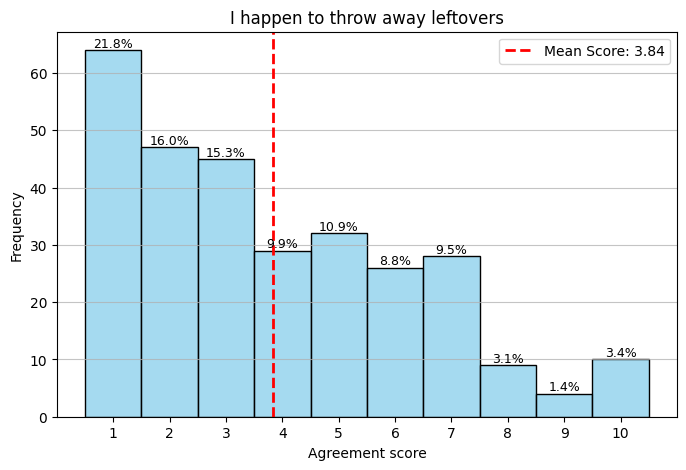

In [36]:
col = 'Q12_2'
plt.figure(figsize=(8, 5))
ax = sns.histplot(df[col], bins=np.arange(overall_min_score, overall_max_score + 2) - 0.5, kde=False, color='skyblue', edgecolor='black', stat='count')
plt.title('I happen to throw away leftovers')
plt.xlabel('Agreement score')
plt.ylabel('Frequency')
plt.xticks(range(int(overall_min_score), int(overall_max_score) + 1))
plt.grid(axis='y', alpha=0.75)


mean_score_x = df[col].mean()
plt.axvline(x=mean_score_x, color='red', linestyle='--', linewidth=2, label=f'Mean Score: {mean_score_x:.2f}')
plt.legend()

for patch in ax.patches:
    x = patch.get_x() + patch.get_width() / 2
    count = patch.get_height()
    total_count = len(df[col])
    percentage = (count / total_count) * 100
    if count > 0:
        ax.text(x, count, f'{percentage:.1f}%', ha='center', va='bottom', fontsize=9, color='black')

plt.show()

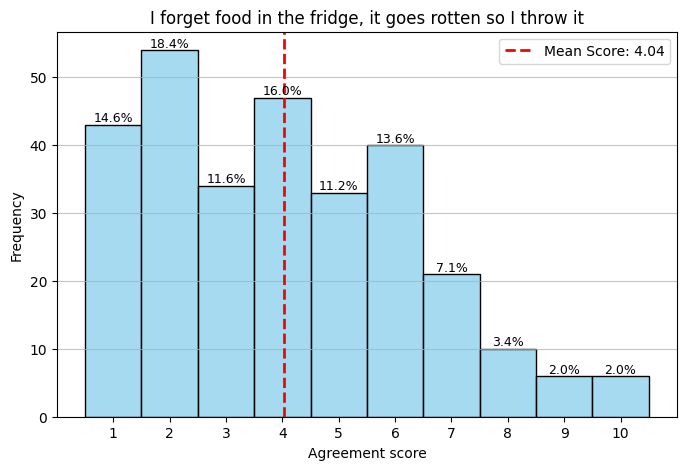

In [37]:
col = 'Q12_3'
plt.figure(figsize=(8, 5))
ax = sns.histplot(df[col], bins=np.arange(overall_min_score, overall_max_score + 2) - 0.5, kde=False, color='skyblue', edgecolor='black', stat='count')
plt.title('I forget food in the fridge, it goes rotten so I throw it')
plt.xlabel('Agreement score')
plt.ylabel('Frequency')
plt.xticks(range(int(overall_min_score), int(overall_max_score) + 1))
plt.grid(axis='y', alpha=0.75)


mean_score_x = df[col].mean()
plt.axvline(x=mean_score_x, color='red', linestyle='--', linewidth=2, label=f'Mean Score: {mean_score_x:.2f}')
plt.legend()

for patch in ax.patches:
    x = patch.get_x() + patch.get_width() / 2
    count = patch.get_height()
    total_count = len(df[col])
    percentage = (count / total_count) * 100
    if count > 0:
        ax.text(x, count, f'{percentage:.1f}%', ha='center', va='bottom', fontsize=9, color='black')

plt.show()

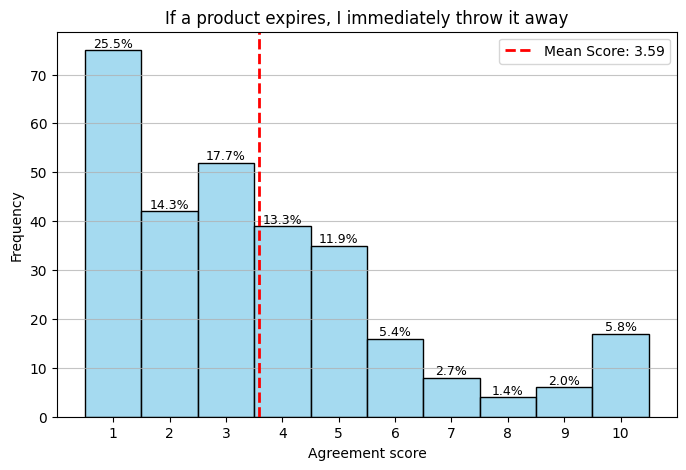

In [38]:
col = 'Q12_4'
plt.figure(figsize=(8, 5))
ax = sns.histplot(df[col], bins=np.arange(overall_min_score, overall_max_score + 2) - 0.5, kde=False, color='skyblue', edgecolor='black', stat='count')
plt.title('If a product expires, I immediately throw it away')
plt.xlabel('Agreement score')
plt.ylabel('Frequency')
plt.xticks(range(int(overall_min_score), int(overall_max_score) + 1))
plt.grid(axis='y', alpha=0.75)


mean_score_x = df[col].mean()
plt.axvline(x=mean_score_x, color='red', linestyle='--', linewidth=2, label=f'Mean Score: {mean_score_x:.2f}')
plt.legend()

for patch in ax.patches:
    x = patch.get_x() + patch.get_width() / 2
    count = patch.get_height()
    total_count = len(df[col])
    percentage = (count / total_count) * 100
    if count > 0:
        ax.text(x, count, f'{percentage:.1f}%', ha='center', va='bottom', fontsize=9, color='black')

plt.show()

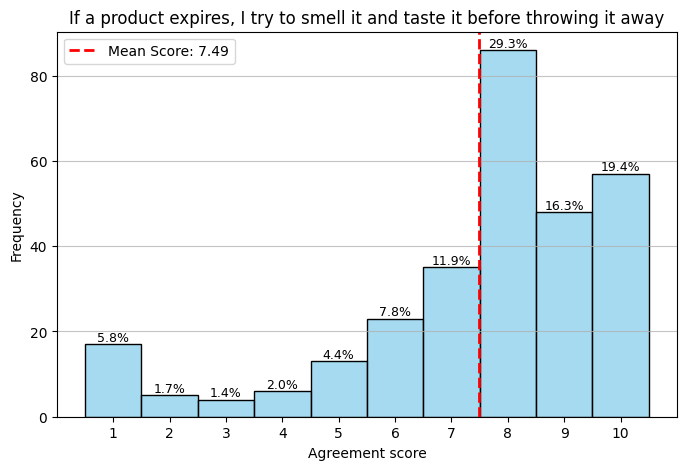

In [39]:
col = 'Q12_5'
plt.figure(figsize=(8, 5))
ax = sns.histplot(df[col], bins=np.arange(overall_min_score, overall_max_score + 2) - 0.5, kde=False, color='skyblue', edgecolor='black', stat='count')
plt.title('If a product expires, I try to smell it and taste it before throwing it away')
plt.xlabel('Agreement score')
plt.ylabel('Frequency')
plt.xticks(range(int(overall_min_score), int(overall_max_score) + 1))
plt.grid(axis='y', alpha=0.75)


mean_score_x = df[col].mean()
plt.axvline(x=mean_score_x, color='red', linestyle='--', linewidth=2, label=f'Mean Score: {mean_score_x:.2f}')
plt.legend()

for patch in ax.patches:
    x = patch.get_x() + patch.get_width() / 2
    count = patch.get_height()
    total_count = len(df[col])
    percentage = (count / total_count) * 100
    if count > 0:
        ax.text(x, count, f'{percentage:.1f}%', ha='center', va='bottom', fontsize=9, color='black')

plt.show()

### Relation Between Age and Food Waste Behaviors

### Age Analysis

In [40]:
min_age = df['Q23'].min()
max_age = df['Q23'].max()
bins = np.append(np.arange(min_age, 60, 10), max_age + 1)
frequency_table_q23 = pd.cut(df['Q23'], bins=bins, right=False, include_lowest=True).value_counts().sort_index()

# Convert to DataFrame and calculate percentages
frequency_table_q23 = frequency_table_q23.to_frame(name='Frequency')
frequency_table_q23['Percentage'] = (frequency_table_q23['Frequency'] / len(df)) * 100
frequency_table_q23['Percentage'] = frequency_table_q23['Percentage'].map(lambda x: f'{x:.2f}%')

display(frequency_table_q23)

,Frequency,Percentage
Q23,,
"[19, 29)",136,46.26%
"[29, 39)",40,13.61%
"[39, 49)",54,18.37%
"[49, 59)",52,17.69%
"[59, 71)",12,4.08%


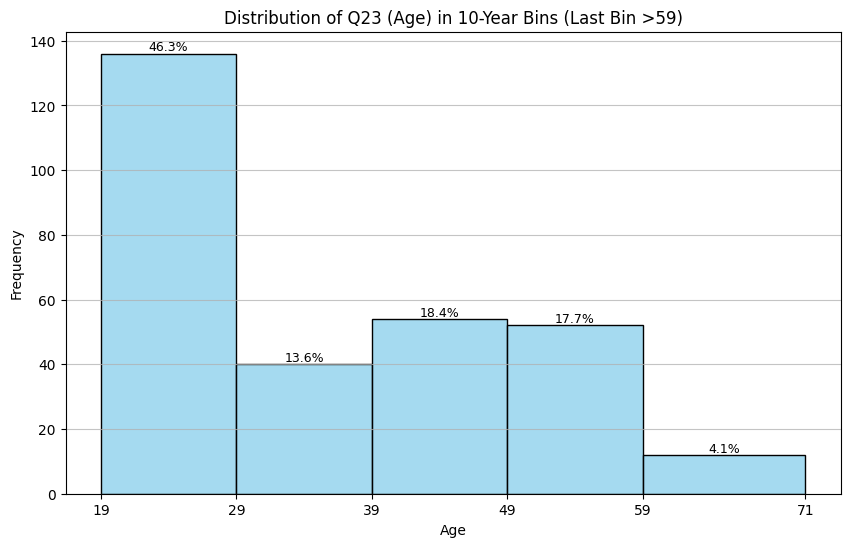

In [41]:


# Create 10-year bins up to 59, then a single bin for >59
# The upper bound for the last bin needs to be max_age + 1 to include max_age
bins = np.append(np.arange(min_age, 60, 10), max_age + 1)

plt.figure(figsize=(10, 6))
ax = sns.histplot(df['Q23'], kde=False, bins=bins, color='skyblue', edgecolor='black', stat='count')
plt.title('Distribution of Q23 (Age) in 10-Year Bins (Last Bin >59)')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.xticks(bins)
plt.grid(axis='y', alpha=0.75)

for patch in ax.patches:
    x = patch.get_x() + patch.get_width() / 2
    count = patch.get_height()
    total_count = len(df['Q23'])
    percentage = (count / total_count) * 100
    if count > 0:
        ax.text(x, count, f'{percentage:.1f}%', ha='center', va='bottom', fontsize=9, color='black')

plt.show()

### Linear Relation?

In [42]:
q12_columns = ['Q12_1', 'Q12_2', 'Q12_3', 'Q12_4', 'Q12_5']

print("Pearson's Correlation (rho) between Q23 (Age) and Q12_x questions:\n")

for col in q12_columns:
    # Calculate Pearson's correlation coefficient
    # df.corr() computes pairwise correlation of columns
    correlation = df['Q23'].corr(df[col])
    print(f"  Q23 vs. {col}: {correlation:.3f}")


Pearson's Correlation (rho) between Q23 (Age) and Q12_x questions:

  Q23 vs. Q12_1: -0.041
  Q23 vs. Q12_2: -0.063
  Q23 vs. Q12_3: -0.018
  Q23 vs. Q12_4: -0.222
  Q23 vs. Q12_5: 0.182


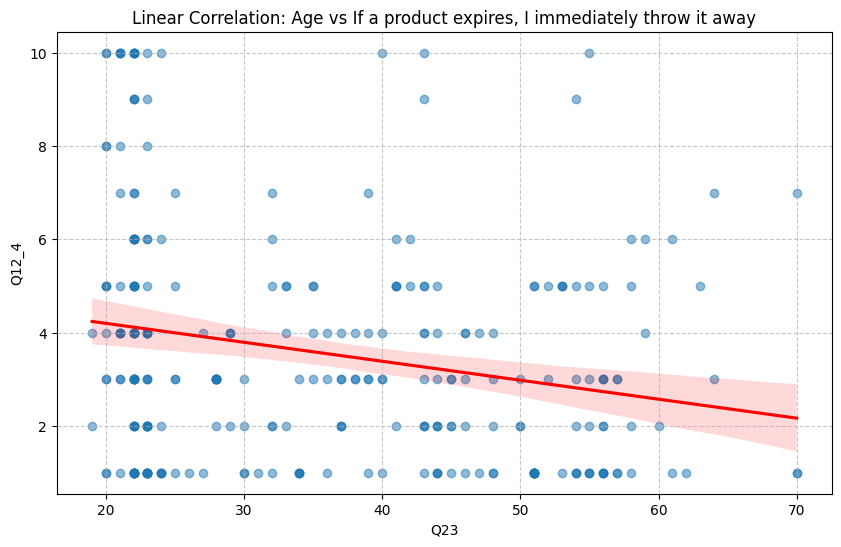

In [43]:
plt.figure(figsize=(10, 6))
sns.regplot(x='Q23', y='Q12_4', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Linear Correlation: Age vs If a product expires, I immediately throw it away')
plt.xlabel('Q23')
plt.ylabel('Q12_4')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

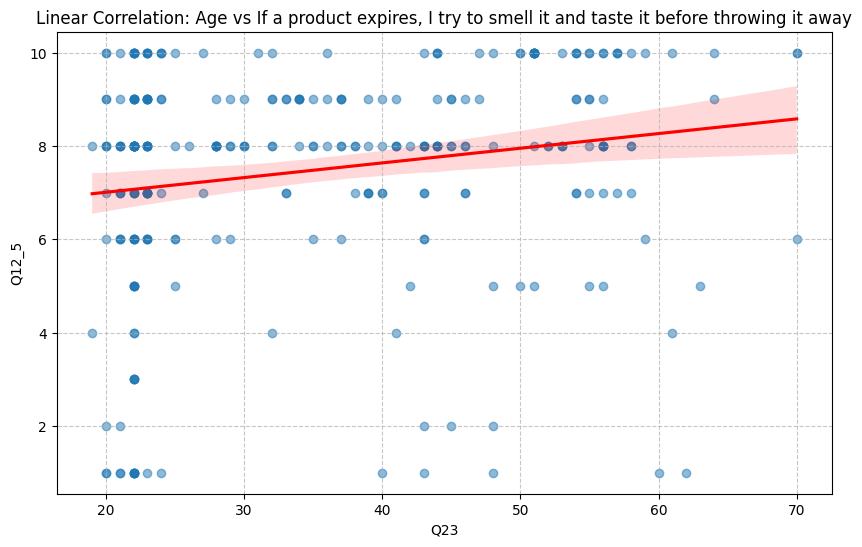

In [44]:
plt.figure(figsize=(10, 6))
sns.regplot(x='Q23', y='Q12_5', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Linear Correlation: Age vs If a product expires, I try to smell it and taste it before throwing it away')
plt.xlabel('Q23')
plt.ylabel('Q12_5')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [48]:
# Define the two age groups for comparison using pandas.Interval objects
# These intervals match the bins created earlier for 'Q23_binned'

# Re-create Q23_binned column in df, as it was not persistently stored.
# Define the bins as used previously for df['Q23'] (min_age=19, max_age=70)
# (These variables are available from previous executed cells)
min_age_survey = df['Q23'].min()
max_age_survey = df['Q23'].max()
bins_for_comparison = [19, 29, 39, 49, 59, max_age_survey + 1]
df['Q23_binned'] = pd.cut(df['Q23'], bins=bins_for_comparison, right=False, include_lowest=True)

group1_age_interval = pd.Interval(left=19, right=29, closed='left')
group2_age_interval = pd.Interval(left=59, right=71, closed='left')

# Filter the DataFrame for each group based on the Q23_binned column
q12_4_group1 = df[df['Q23_binned'] == group1_age_interval]['Q12_4']
q12_4_group2 = df[df['Q23_binned'] == group2_age_interval]['Q12_4']

print(f"Comparing mean Q12_4 scores between age group {group1_age_interval} and {group2_age_interval}")

# Check if both groups have enough data for a t-test
if len(q12_4_group1) > 1 and len(q12_4_group2) > 1:
    # Perform independent samples t-test (Welch's t-test, as it doesn't assume equal variances)
    t_stat, p_value = stats.ttest_ind(q12_4_group1,q12_4_group2, equal_var=False)

    print(f"\nMean Q12_4 for age group {group1_age_interval}: {q12_4_group1.mean():.2f}")
    print(f"Mean Q12_4 for age group {group2_age_interval}: {q12_4_group2.mean():.2f}")
    print(f"T-statistic: {t_stat:.3f}")
    print(f"P-value: {p_value:.3f}")
    print("Alpha: 0.05")
    print(f"Degrees of Freedom: {len(q12_4_group1) + len(q12_4_group2) - 2}")

    alpha = 0.05
    if p_value < alpha:
        print(f"\nConclusion: With a p-value of {p_value:.3f}, which is less than {alpha}, we reject the null hypothesis.")
    else:
        print(f"\nConclusion: With a p-value of {p_value:.3f}, which is greater than {alpha}, we fail to reject the null hypothesis.")
else:
    print("One or both selected age groups do not have enough data to perform a t-test. Please ensure groups have at least 2 observations.")

Comparing mean Q12_4 scores between age group [19, 29) and [59, 71)

Mean Q12_4 for age group [19, 29): 4.19
Mean Q12_4 for age group [59, 71): 3.67
T-statistic: 0.698
P-value: 0.497
Alpha: 0.05
Degrees of Freedom: 146

Conclusion: With a p-value of 0.497, which is greater than 0.05, we fail to reject the null hypothesis.


In [47]:
# Define the two age groups for comparison using pandas.Interval objects
# These intervals match the bins created earlier for 'Q23_binned'
group1_age_interval = pd.Interval(left=19, right=29, closed='left')
group2_age_interval = pd.Interval(left=59, right=71, closed='left')

# Filter the DataFrame for each group based on the Q23_binned column
q12_5_group1 = df[df['Q23_binned'] == group1_age_interval]['Q12_5']
q12_5_group2 = df[df['Q23_binned'] == group2_age_interval]['Q12_5']

print(f"Comparing mean Q12_5 scores between age group {group1_age_interval} and {group2_age_interval}")

# Check if both groups have enough data for a t-test
if len(q12_5_group1) > 1 and len(q12_5_group2) > 1:
    # Perform independent samples t-test (Welch's t-test, as it doesn't assume equal variances)
    t_stat, p_value = stats.ttest_ind(q12_5_group1,q12_5_group2, equal_var=False)

    print(f"\nMean Q12_5 for age group {group1_age_interval}: {q12_5_group1.mean():.2f}")
    print(f"Mean Q12_5 for age group {group2_age_interval}: {q12_5_group2.mean():.2f}")
    print(f"T-statistic: {t_stat:.3f}")
    print(f"P-value: {p_value:.3f}")
    print("Alpha: 0.05")
    print(f"Degrees of Freedom: {len(q12_5_group1) + len(q12_5_group2) - 2}")

    alpha = 0.05
    if p_value < alpha:
        print(f"\nConclusion: With a p-value of {p_value:.3f}, which is less than {alpha}, we reject the null hypothesis.")
    else:
        print(f"\nConclusion: With a p-value of {p_value:.3f}, which is greater than {alpha}, we fail to reject the null hypothesis.")
else:
    print("One or both selected age groups do not have enough data to perform a t-test. Please ensure groups have at least 2 observations.")


Comparing mean Q12_5 scores between age group [19, 29) and [59, 71)

Mean Q12_5 for age group [19, 29): 7.00
Mean Q12_5 for age group [59, 71): 6.83
T-statistic: 0.161
P-value: 0.875
Alpha: 0.05
Degrees of Freedom: 146

Conclusion: With a p-value of 0.875, which is greater than 0.05, we fail to reject the null hypothesis.


# Attitudes of Potential and Existing Users

## Willingness to Pay by Store Category

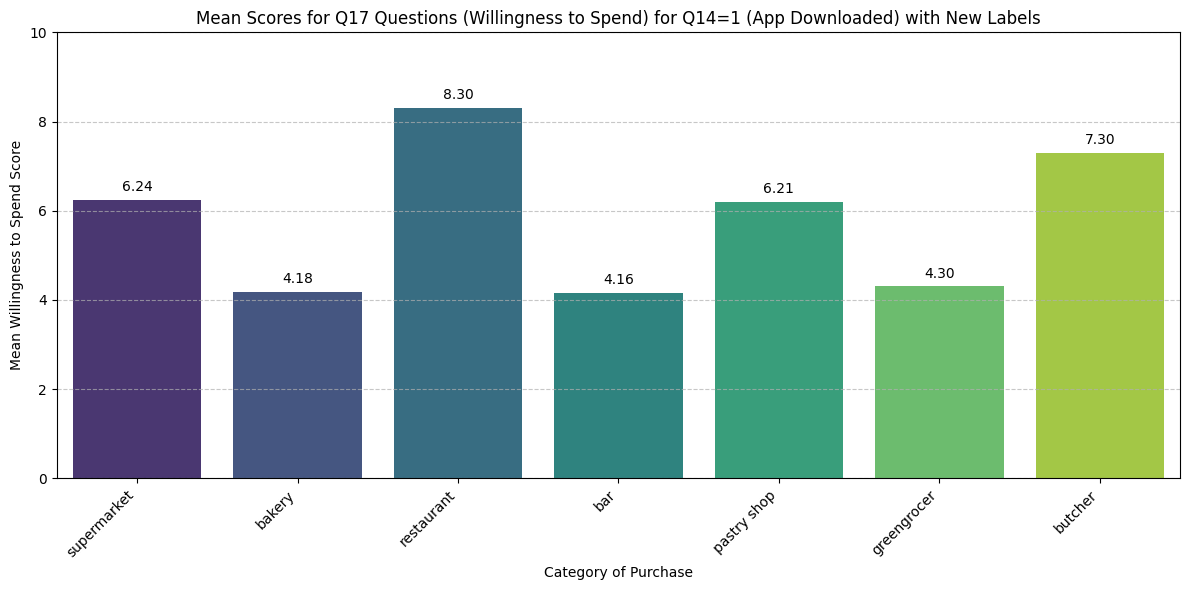

In [49]:
q17_columns_original = ['Q17_1', 'Q17_2', 'Q17_3', 'Q17_4', 'Q17_5', 'Q17_6', 'Q17_7']
new_q17_labels = [
    'supermarket', 'bakery', 'restaurant', 'bar', 'pastry shop', 'greengrocer', 'butcher'
]

# Create a dictionary for renaming
rename_mapping = dict(zip(q17_columns_original, new_q17_labels))

# Rename columns in the DataFrame
# Make a copy to ensure we don't modify the original df for other analyses if it's used later
df_renamed = df.rename(columns=rename_mapping)

# Filter the DataFrame to include only those who answered 1 to Q14
df_filtered_q14_yes = df_renamed[df_renamed['Q14'] == 1].copy()

# Calculate mean for the newly named Q17 questions from the filtered DataFrame
q17_mean_values_renamed = df_filtered_q14_yes[new_q17_labels].mean().reset_index()
q17_mean_values_renamed.columns = ['Question', 'Mean_Score']

plt.figure(figsize=(12, 6))
# Addressing the FutureWarning: Pass 'Question' to 'hue' and set 'legend=False'
ax = sns.barplot(x='Question', y='Mean_Score', data=q17_mean_values_renamed, hue='Question', palette='viridis', legend=False)
plt.title('Mean Scores for Q17 Questions (Willingness to Spend) for Q14=1 (App Downloaded) with New Labels')
plt.xlabel('Category of Purchase')
plt.ylabel('Mean Willingness to Spend Score')
plt.ylim(0, 10) # Assuming a 1-10 scale for Q17 questions
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add mean values on top of bars
for index, row in q17_mean_values_renamed.iterrows():
    ax.text(index, row['Mean_Score'] + 0.2, f'{row['Mean_Score']:.2f}', color='black', ha="center")

plt.tight_layout()
plt.show()

## Which Time Span is Preferred?

### Frequency Table for Ideal Waiting Time (5-Minute Bins)

In [50]:
# Define 5-minute bins for Q18. The last bin should capture values >=35.
max_q18_val = df['Q18'].max()

# Create bin edges up to 35 in 5-minute intervals
bin_edges = list(np.arange(0, 36, 5)) # Bins: [0,5), [5,10), ..., [30,35)

# Add an upper bound for the last bin (values >= 35)
# Ensure it covers the maximum observed value if it's 35 or greater.
if max_q18_val >= 35:
    # The last edge should be just above the max_q18_val to include it
    bin_edges.append(max_q18_val + 1)

# Create labels for the bins
# Labels for standard 5-minute intervals
bin_labels = [f'[{bin_edges[i]}, {bin_edges[i+1]})' for i in range(len(bin_edges) - 2)]

# Label for the last bin (>=35)
if len(bin_edges) > 1: # Ensure there are enough edges to form a bin
    bin_labels.append(f'>={bin_edges[-2]}')

# Create a new column with binned Q18 values
# pd.cut handles the binning logic, `right=False` means [inclusive, exclusive)
df['Q18_binned'] = pd.cut(df['Q18'], bins=bin_edges, labels=bin_labels, right=False, include_lowest=True)

# Calculate frequency and percentage for the binned Q18 values
frequency_table_q18_binned = df['Q18_binned'].value_counts().sort_index().reset_index()
frequency_table_q18_binned.columns = ['Time_Bin', 'Frequency']
frequency_table_q18_binned['Percentage'] = (frequency_table_q18_binned['Frequency'] / len(df)) * 100

# Format percentage column
frequency_table_q18_binned['Percentage'] = frequency_table_q18_binned['Percentage'].map(lambda x: f'{x:.2f}%')

display(frequency_table_q18_binned)

,Time_Bin,Frequency,Percentage
0,"[0, 5)",21,7.14%
1,"[5, 10)",78,26.53%
2,"[10, 15)",94,31.97%
3,"[15, 20)",58,19.73%
4,"[20, 25)",23,7.82%
5,"[25, 30)",7,2.38%
6,"[30, 35)",10,3.40%
7,>=35,3,1.02%


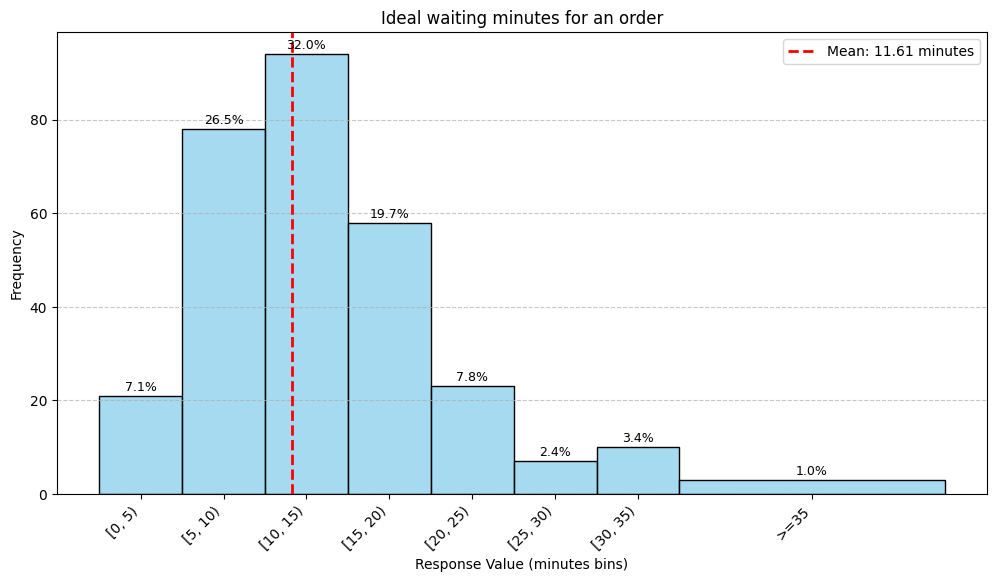

In [51]:
col = 'Q18'

plt.figure(figsize=(12, 6))
ax = sns.histplot(x=df[col], bins=bin_edges, color='skyblue', edgecolor='black', stat='count')
plt.title('Ideal waiting minutes for an order') # Updated title
plt.xlabel('Response Value (minutes bins)')
plt.ylabel('Frequency')

# Calculate bin centers for xticks to align with descriptive bin labels
bin_centers = [(bin_edges[i] + bin_edges[i+1]) / 2 for i in range(len(bin_edges) - 1)]
plt.xticks(ticks=bin_centers, labels=bin_labels, rotation=45, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add percentage labels to the bars
total_original_count = len(df[col])
for patch in ax.patches:
    x = patch.get_x() + patch.get_width() / 2.0 # Center of the bar
    height = patch.get_height()
    percentage = (height / total_original_count) * 100
    if height > 0: # Only display label if the bar has a height
        ax.text(x, height + 0.5, f'{percentage:.1f}%', ha='center', va='bottom', fontsize=9, color='black')

# Add vertical line for the mean
mean_q18 = df['Q18'].mean()
plt.axvline(x=mean_q18, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_q18:.2f} minutes')
plt.legend()

plt.show()

## Expected Number of Items in the Magic Box

=== DESCRIPTIVE STATISTICS ===
Mean: 4.66
Median: 5.00
Mode: 5.00
Standard Deviation: 1.36
Minimum: 1
Maximum: 9
Q1 (25%): 4.00
Q3 (75%): 5.00


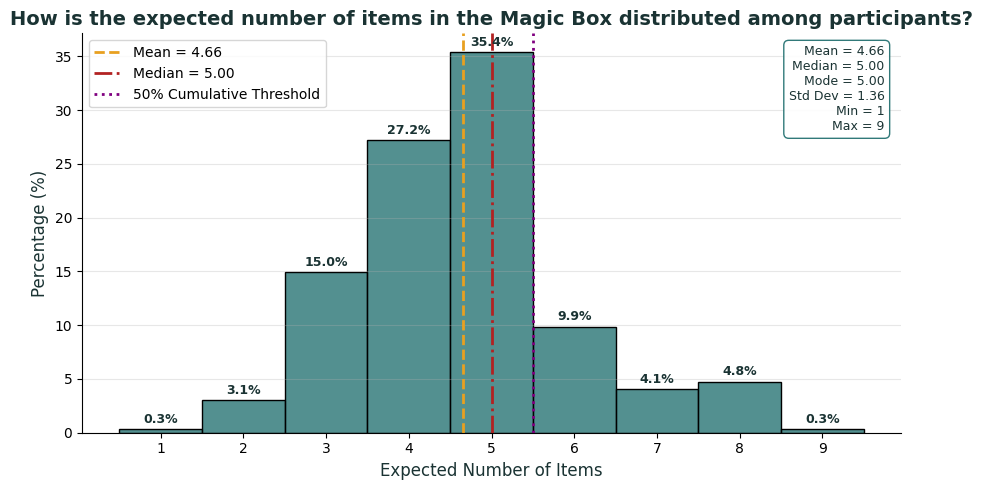

In [52]:
col = 'Q19'

df_clean = df[[col]].dropna()



mean_value = df_clean[col].mean()

median_value = df_clean[col].median()

mode_value = df_clean[col].mode()[0]

std_value = df_clean[col].std()

min_value = df_clean[col].min()

max_value = df_clean[col].max()

q1 = df_clean[col].quantile(0.25)

q3 = df_clean[col].quantile(0.75)



print("=== DESCRIPTIVE STATISTICS ===")

print(f"Mean: {mean_value:.2f}")

print(f"Median: {median_value:.2f}")

print(f"Mode: {mode_value:.2f}")

print(f"Standard Deviation: {std_value:.2f}")

print(f"Minimum: {min_value}")

print(f"Maximum: {max_value}")

print(f"Q1 (25%): {q1:.2f}")

print(f"Q3 (75%): {q3:.2f}")



overall_min_score = int(df_clean[col].min())

overall_max_score = int(df_clean[col].max())

fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(
    df_clean[col],
    bins=np.arange(overall_min_score, overall_max_score + 2) - 0.5,
    kde=False,
    color='#1A6B6B',
    edgecolor='black',
    stat='percent',
    ax=ax
)




for patch in ax.patches:

    x = patch.get_x() + patch.get_width() / 2

    y = patch.get_height()

    if y > 0:

        ax.text(
            x,
            y + 0.3,
            f'{y:.1f}%',
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold',
            color='#1A3333'
        )


ax.axvline(
    mean_value,
    color='#E8A020',
    linestyle='--',
    linewidth=2,
    label=f'Mean = {mean_value:.2f}'
)



ax.axvline(
    median_value,
    color='#B22222',
    linestyle='-.',
    linewidth=2,
    label=f'Median = {median_value:.2f}'
)



score_counts = (
    df_clean[col]
    .value_counts(normalize=True)
    .sort_index() * 100
)

cumulative_percentage = 0

threshold_score_x = None

for score, percent in score_counts.items():

    cumulative_percentage += percent

    if cumulative_percentage >= 50:

        threshold_score_x = score + 0.5

        break

if threshold_score_x is not None:

    ax.axvline(
        x=threshold_score_x,
        color='purple',
        linestyle=':',
        linewidth=2,
        label='50% Cumulative Threshold'
    )



ax.text(
    0.98,
    0.97,
    f'Mean = {mean_value:.2f}\n'
    f'Median = {median_value:.2f}\n'
    f'Mode = {mode_value:.2f}\n'
    f'Std Dev = {std_value:.2f}\n'
    f'Min = {min_value}\n'
    f'Max = {max_value}',
    transform=ax.transAxes,
    ha='right',
    va='top',
    fontsize=9,
    color='#1A3333',
    bbox=dict(
        boxstyle='round,pad=0.4',
        facecolor='white',
        edgecolor='#1A6B6B',
        alpha=0.9
    )
)



ax.set_title(
    'How is the expected number of items in the Magic Box distributed among participants?',
    fontsize=14,
    fontweight='bold',
    color='#1A3333'
)

ax.set_xlabel(
    'Expected Number of Items',
    fontsize=12,
    color='#1A3333'
)

ax.set_ylabel(
    'Percentage (%)',
    fontsize=12,
    color='#1A3333'
)

ax.set_xticks(
    range(overall_min_score, overall_max_score + 1)
)

ax.grid(axis='y', alpha=0.3)

ax.legend(fontsize=10)

ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()

plt.show()

## WTP vs Expected Quantity by Store Type

=== CORRELATION RESULTS ===

Supermarket
  Average WTP = €6.37
  r = 0.137
  p = 0.0185
  R² = 0.019
  Strength = Weak

Bakery
  Average WTP = €4.34
  r = 0.156
  p = 0.0073
  R² = 0.024
  Strength = Weak

Restaurant
  Average WTP = €8.23
  r = 0.183
  p = 0.0016
  R² = 0.033
  Strength = Weak

Bar
  Average WTP = €4.22
  r = 0.207
  p = 0.0003
  R² = 0.043
  Strength = Weak

Pastry shop
  Average WTP = €6.09
  r = 0.196
  p = 0.0007
  R² = 0.038
  Strength = Weak

Greengrocer
  Average WTP = €4.70
  r = 0.175
  p = 0.0026
  R² = 0.031
  Strength = Weak

Butcher
  Average WTP = €7.39
  r = 0.252
  p = 0.0000
  R² = 0.063
  Strength = Weak


=== CORRELATION SUMMARY TABLE ===
      Category  Average WTP (€)  Correlation  p-value     R² Strength
6      Butcher            7.388        0.252    0.000  0.063     Weak
3          Bar            4.224        0.207    0.000  0.043     Weak
4  Pastry shop            6.092        0.196    0.001  0.038     Weak
2   Restaurant            8.228      

/tmp/ipykernel_7036/746970594.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


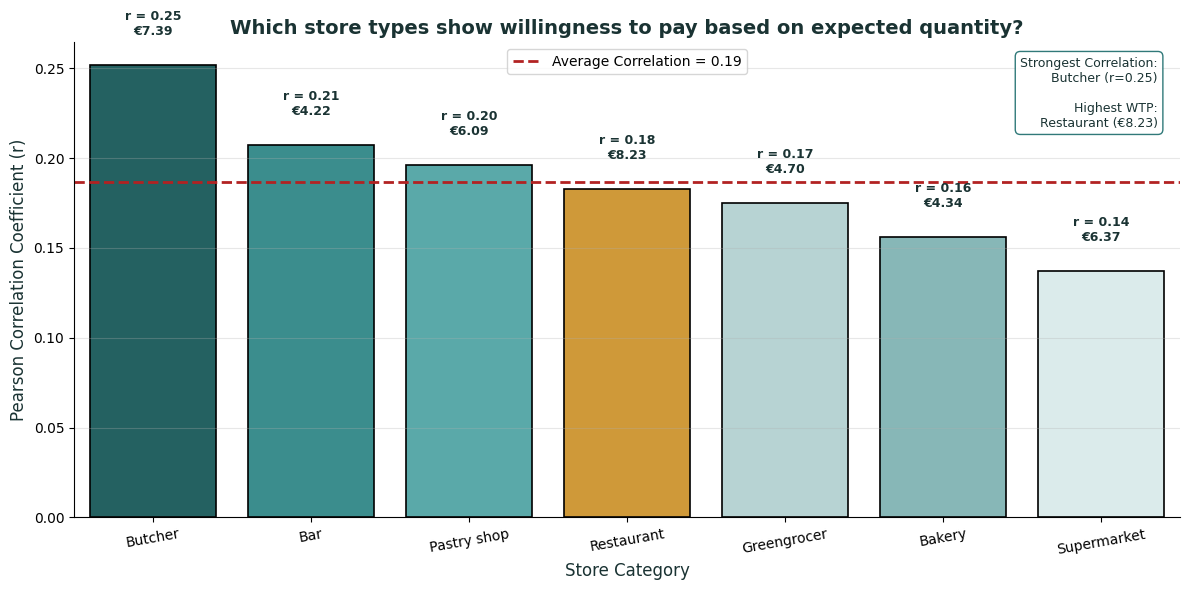

In [53]:

q17_columns = [
    'Q17_1',
    'Q17_2',
    'Q17_3',
    'Q17_4',
    'Q17_5',
    'Q17_6',
    'Q17_7'
]

category_names = [
    'Supermarket',
    'Bakery',
    'Restaurant',
    'Bar',
    'Pastry shop',
    'Greengrocer',
    'Butcher'
]



results = []

print("=== CORRELATION RESULTS ===\n")

for col, category in zip(q17_columns, category_names):

    # Clean dataframe
    temp_df = df[['Q19', col]].dropna()

    # Pearson correlation
    correlation, p_value = stats.pearsonr(
        temp_df['Q19'],
        temp_df[col]
    )

    # R²
    r_squared = correlation ** 2

    # Average willingness to pay
    average_wtp = temp_df[col].mean()

    # Interpretation
    if abs(correlation) < 0.1:
        strength = 'Negligible'

    elif abs(correlation) < 0.3:
        strength = 'Weak'

    elif abs(correlation) < 0.5:
        strength = 'Moderate'

    else:
        strength = 'Strong'

    # Store results
    results.append({
        'Category': category,
        'Average WTP (€)': average_wtp,
        'Correlation': correlation,
        'p-value': p_value,
        'R²': r_squared,
        'Strength': strength
    })

    # Print results
    print(f"{category}")
    print(f"  Average WTP = €{average_wtp:.2f}")
    print(f"  r = {correlation:.3f}")
    print(f"  p = {p_value:.4f}")
    print(f"  R² = {r_squared:.3f}")
    print(f"  Strength = {strength}\n")


corr_df = pd.DataFrame(results)

# Sort strongest correlations first
corr_df = corr_df.sort_values(
    by='Correlation',
    ascending=False
)



print("\n=== CORRELATION SUMMARY TABLE ===")

print(
    corr_df[
        [
            'Category',
            'Average WTP (€)',
            'Correlation',
            'p-value',
            'R²',
            'Strength'
        ]
    ].round(3)
)



fig, ax = plt.subplots(figsize=(12, 6))

bars = sns.barplot(
    data=corr_df,
    x='Category',
    y='Correlation',
    palette=[
        '#1A6B6B',
        '#2D9B9B',
        '#4DB6B6',
        '#E8A020',
        '#B2D8D8',
        '#7FBFBF',
        '#D9EDED'
    ],
    edgecolor='black',
    linewidth=1.2,
    ax=ax
)



for i, patch in enumerate(ax.patches):

    height = patch.get_height()

    avg_price = corr_df.iloc[i]['Average WTP (€)']

    ax.text(
        patch.get_x() + patch.get_width()/2,
        height + 0.015,
        f'r = {height:.2f}\n€{avg_price:.2f}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold',
        color='#1A3333'
    )



average_corr = corr_df['Correlation'].mean()

ax.axhline(
    average_corr,
    color='#B22222',
    linestyle='--',
    linewidth=2,
    label=f'Average Correlation = {average_corr:.2f}'
)



strongest_category = corr_df.iloc[0]['Category']
strongest_corr = corr_df.iloc[0]['Correlation']

highest_wtp_category = corr_df.loc[
    corr_df['Average WTP (€)'].idxmax(),
    'Category'
]

highest_wtp = corr_df['Average WTP (€)'].max()

ax.text(
    0.98,
    0.97,
    f'Strongest Correlation:\n'
    f'{strongest_category} (r={strongest_corr:.2f})\n\n'
    f'Highest WTP:\n'
    f'{highest_wtp_category} (€{highest_wtp:.2f})',
    transform=ax.transAxes,
    ha='right',
    va='top',
    fontsize=9,
    color='#1A3333',
    bbox=dict(
        boxstyle='round,pad=0.4',
        facecolor='white',
        edgecolor='#1A6B6B',
        alpha=0.9
    )
)



ax.set_title(
    'Which store types show willingness to pay based on expected quantity?',
    fontsize=14,
    fontweight='bold',
    color='#1A3333'
)

ax.set_xlabel(
    'Store Category',
    fontsize=12,
    color='#1A3333'
)

ax.set_ylabel(
    'Pearson Correlation Coefficient (r)',
    fontsize=12,
    color='#1A3333'
)

ax.grid(axis='y', alpha=0.3)

ax.legend(fontsize=10)

ax.spines[['top', 'right']].set_visible(False)

plt.xticks(rotation=10)

plt.tight_layout()

plt.show()

## Does Household Size Affect the Expected Number of Items?

In [57]:
df['Q19'] = pd.to_numeric(df['Q19'], errors='coerce')
df['Q28'] = pd.to_numeric(df['Q28'], errors='coerce')

df_clean = df[['Q19', 'Q28']].dropna()

# Optional: cap extreme values if needed
df_clean = df_clean[df_clean['Q28'] <= 7]

print(f"Sample size: {len(df_clean)}")

group_means = df_clean.groupby('Q28')['Q19'].agg(['mean', 'count'])

print("\n=== MEAN EXPECTED ITEMS BY HOUSEHOLD SIZE ===")
print(group_means)

Sample size: 294

=== MEAN EXPECTED ITEMS BY HOUSEHOLD SIZE ===
         mean  count
Q28                 
1    4.714286     49
2    4.541284    109
3    4.608696     69
4    4.844444     45
5    5.058824     17
6    5.000000      2
7    4.000000      3


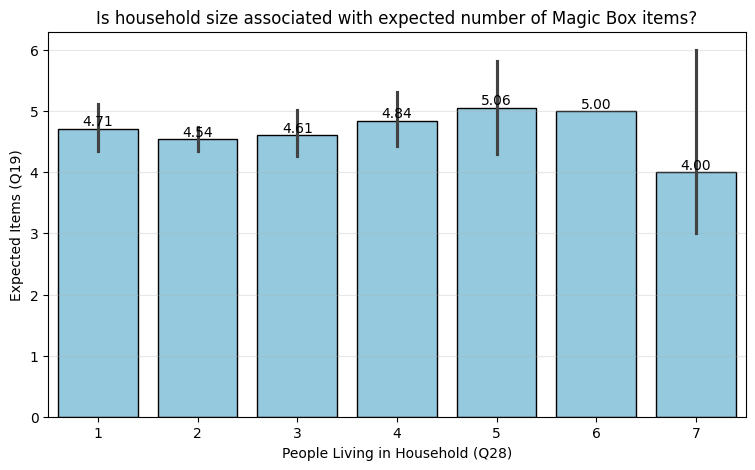


=== ANOVA RESULTS ===
F-statistic: 0.689
p-value: 0.6590

→ No significant relationship between household size and expected items.

=== INSIGHT ===
Highest expectation: 5 people in household
Lowest expectation: 7 people in household


In [60]:
plt.figure(figsize=(9,5))

ax = sns.barplot(data=df_clean, x='Q28', y='Q19',color='skyblue',edgecolor='black'
)

plt.title('Is household size associated with expected number of Magic Box items?')
plt.xlabel('People Living in Household (Q28)')
plt.ylabel('Expected Items (Q19)')
plt.grid(axis='y', alpha=0.3)

# Add labels
means = df_clean.groupby('Q28')['Q19'].mean()

for i, v in enumerate(means):
    ax.text(i, v + 0.05, f'{v:.2f}',
            ha='center')
plt.show()

groups = [df_clean[df_clean['Q28'] == i]['Q19'].dropna()
    for i in sorted(df_clean['Q28'].unique())]

f_stat, p_value = stats.f_oneway(*groups)

print("\n=== ANOVA RESULTS ===")
print(f"F-statistic: {f_stat:.3f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("\n→ Significant relationship between household size and expected items.")
else:
    print("\n→ No significant relationship between household size and expected items.")

trend = df_clean.groupby('Q28')['Q19'].mean()

highest = trend.idxmax()
lowest = trend.idxmin()

print("\n=== INSIGHT ===")
print(f"Highest expectation: {highest} people in household")
print(f"Lowest expectation: {lowest} people in household")

##Self-pickup aversion and willingness

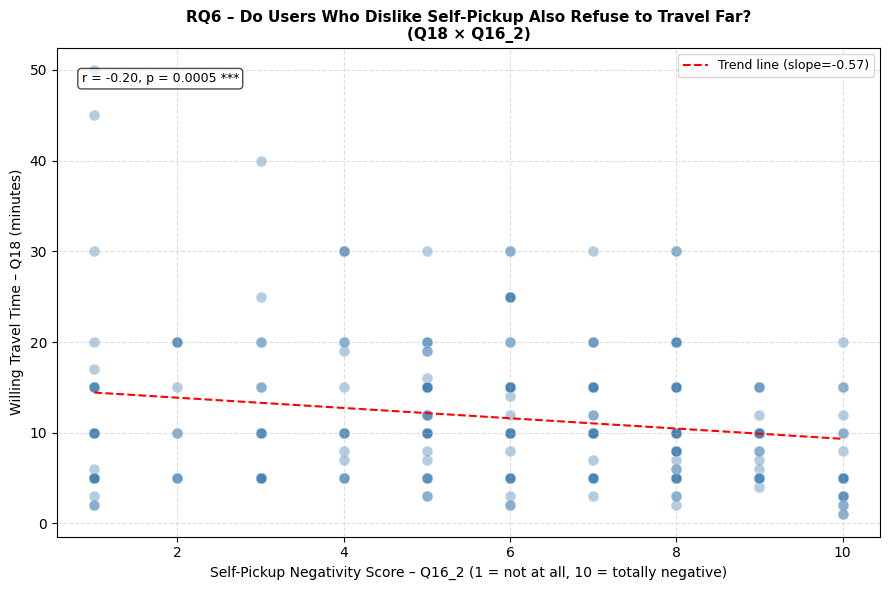


Pearson Correlation – Q18 vs Q16_2
  r = -0.201
  p = 0.0005 ***


In [55]:
df_scatter = df[['Q18', 'Q16_2']].dropna()

corr_x = df_scatter['Q16_2']
corr_y = df_scatter['Q18']

r, p = stats.pearsonr(corr_x, corr_y)
sig  = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))

m, b   = np.polyfit(corr_x, corr_y, 1)
x_line = np.linspace(corr_x.min(), corr_x.max(), 100)

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(corr_x, corr_y, color='steelblue', alpha=0.4,
           edgecolors='white', linewidth=0.4, s=60)

ax.plot(x_line, m * x_line + b, color='red', linewidth=1.5,
        linestyle='--', label=f'Trend line (slope={m:.2f})')

ax.text(0.03, 0.95, f'r = {r:.2f}, p = {p:.4f} {sig}',
        transform=ax.transAxes, fontsize=9,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

ax.set_xlabel('Self-Pickup Negativity Score – Q16_2 (1 = not at all, 10 = totally negative)', fontsize=10)
ax.set_ylabel('Willing Travel Time – Q18 (minutes)', fontsize=10)
ax.set_title('RQ6 – Do Users Who Dislike Self-Pickup Also Refuse to Travel Far?\n(Q18 × Q16_2)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print(f'\nPearson Correlation – Q18 vs Q16_2')
print(f'  r = {r:.3f}')
print(f'  p = {p:.4f} {sig}')

# Cluster Analysis

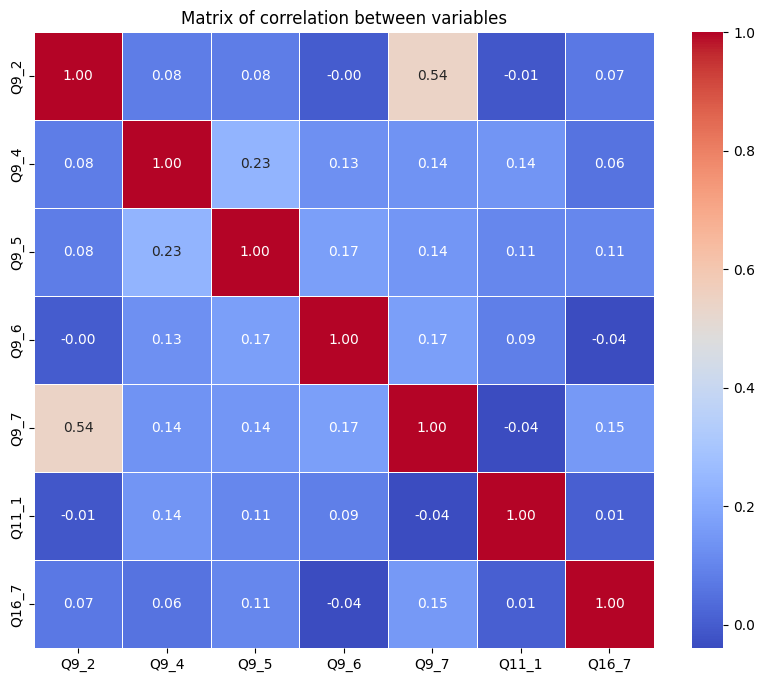

In [69]:
correlation_variables = ['Q9_2', 'Q9_4', 'Q9_5', 'Q9_6', 'Q9_7', 'Q11_1', 'Q16_7']

# Calculate the correlation matrix
correlation_matrix = df[correlation_variables].corr()

# Display the correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=.5
)
plt.title('Matrix of correlation between variables')
plt.show()

### K-Means Clustering Analysis

In [70]:


# Define the variables for clustering
clustering_variables = ['Q9_4', 'Q9_5', 'Q9_6', 'Q9_7', 'Q11_1', 'Q16_7']

# Create a DataFrame with only the clustering variables
df_clustering = df[clustering_variables].copy()

# Check for and handle any potential missing values (though these columns should be clean)
# In this case, previous steps have already filled NaNs, but a check is good practice.
if df_clustering.isnull().sum().any():
    print("Warning: Missing values detected in clustering variables. Handling with dropna().")
    df_clustering = df_clustering.dropna()

# Scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_clustering)

# Convert scaled data back to a DataFrame for easier manipulation (optional, but good for understanding)
scaled_df = pd.DataFrame(scaled_data, columns=clustering_variables, index=df_clustering.index)

In [63]:
n_clusters_options = [3, 4, 5, 6]

results_cluster_distribution = []

for n_clusters in n_clusters_options:
    print(f"\n--- K-Means Clustering with {n_clusters} Clusters ---")

    # Initialize and fit KMeans model
    # n_init=10 is used to run KMeans multiple times with different centroid seeds
    # and chooses the best result, which helps to mitigate the algorithm's sensitivity to initial centroid placement.
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    kmeans.fit(scaled_data)

    # Get cluster labels
    cluster_labels = kmeans.labels_

    # Add cluster labels to the original (or scaled) DataFrame for analysis
    df_clustering_with_labels = df_clustering.copy()
    df_clustering_with_labels['Cluster'] = cluster_labels

    # Calculate cluster distribution
    cluster_distribution = df_clustering_with_labels['Cluster'].value_counts().sort_index()
    cluster_percentage = (cluster_distribution / len(df_clustering_with_labels)) * 100

    # Combine distribution and percentage into a single DataFrame
    distribution_df = pd.DataFrame({
        'Count': cluster_distribution,
        'Percentage': cluster_percentage.map(lambda x: f'{x:.2f}%')
    })

    print("Cluster Distribution:")
    display(distribution_df)

    results_cluster_distribution.append({
        'n_clusters': n_clusters,
        'distribution': distribution_df
    })


--- K-Means Clustering with 3 Clusters ---
Cluster Distribution:


,Count,Percentage
Cluster,,
0,76,25.85%
1,97,32.99%
2,121,41.16%



--- K-Means Clustering with 4 Clusters ---
Cluster Distribution:


,Count,Percentage
Cluster,,
0,87,29.59%
1,27,9.18%
2,71,24.15%
3,109,37.07%



--- K-Means Clustering with 5 Clusters ---
Cluster Distribution:


,Count,Percentage
Cluster,,
0,66,22.45%
1,101,34.35%
2,44,14.97%
3,62,21.09%
4,21,7.14%



--- K-Means Clustering with 6 Clusters ---
Cluster Distribution:


,Count,Percentage
Cluster,,
0,43,14.63%
1,60,20.41%
2,49,16.67%
3,18,6.12%
4,62,21.09%
5,62,21.09%


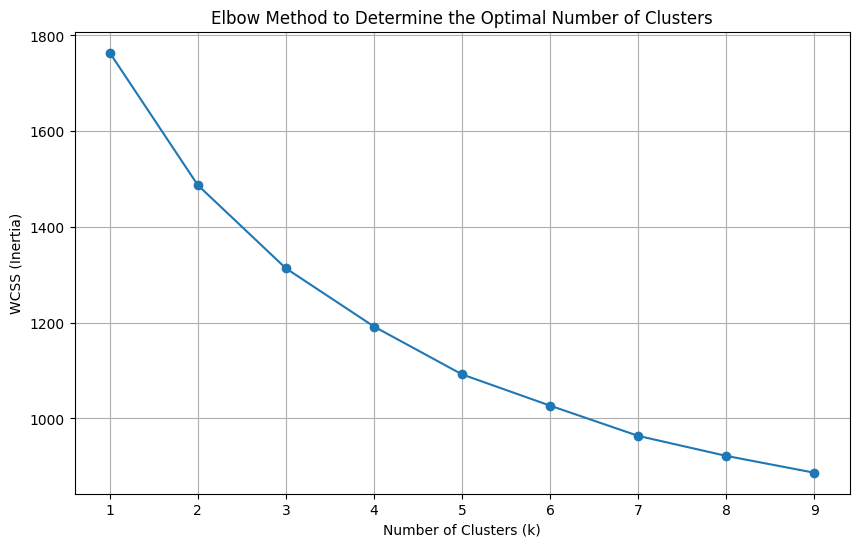

Observe the graph and look for a pronounced 'elbow'. The point where the decrease in WCSS significantly slows down is often considered the optimal number of clusters.

Slope of the WCSS curve (decrease in WCSS for each additional cluster):
  From k=1 to k=2: WCSS decrease = 276.65
  From k=2 to k=3: WCSS decrease = 173.80
  From k=3 to k=4: WCSS decrease = 121.58
  From k=4 to k=5: WCSS decrease = 99.99
  From k=5 to k=6: WCSS decrease = 65.33
  From k=6 to k=7: WCSS decrease = 63.14
  From k=7 to k=8: WCSS decrease = 41.81
  From k=8 to k=9: WCSS decrease = 35.19


In [75]:
n_clusters_options = [3, 4, 5, 6]

wcss = [] # Within-Cluster Sum of Squares
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

# Traccia il grafico del gomito
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='-')
plt.title('Elbow Method to Determine the Optimal Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

print("Observe the graph and look for a pronounced 'elbow'. The point where the decrease in WCSS significantly slows down is often considered the optimal number of clusters.")

# Calcola e stampa l'"inclinazione" della curva (la diminuzione del WCSS)
print("\nSlope of the WCSS curve (decrease in WCSS for each additional cluster):")
for i in range(1, len(wcss)):
    k_value = k_range[i] # Corrisponde al numero di cluster raggiunto
    prev_wcss = wcss[i-1]
    current_wcss = wcss[i]
    decrease = prev_wcss - current_wcss
    print(f"  From k={k_range[i-1]} to k={k_value}: WCSS decrease = {decrease:.2f}")

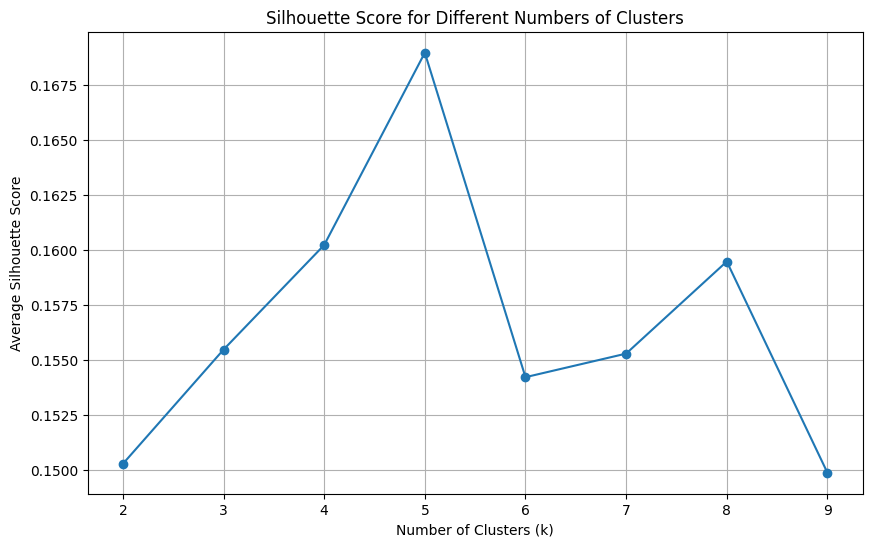

Look for the 'k' value that corresponds to the highest silhouette score. This indicates denser and well-separated clusters.


In [76]:
# Rimuovi k=1 dal range per il punteggio di silhouette, in quanto non è definibile per un singolo cluster
k_range_silhouette = range(2, 10)

silhouette_scores = []
for k in k_range_silhouette:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    score = silhouette_score(scaled_data, kmeans.labels_)
    silhouette_scores.append(score)

# Traccia il grafico del punteggio di silhouette
plt.figure(figsize=(10, 6))
plt.plot(k_range_silhouette, silhouette_scores, marker='o', linestyle='-')
plt.title('Silhouette Score for Different Numbers of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Average Silhouette Score')
plt.xticks(k_range_silhouette)
plt.grid(True)
plt.show()

print("Look for the 'k' value that corresponds to the highest silhouette score. This indicates denser and well-separated clusters.")

In [77]:
# Ensure df_clustering and scaled_data are available
# (These should have been created and scaled in previous steps)
if 'df_clustering' not in locals() or 'scaled_data' not in locals():
    print("Error: 'df_clustering' or 'scaled_data' have not been defined. Make sure you have executed the previous cells.")
else:
    clustering_variables = ['Q9_4', 'Q9_5', 'Q9_6', 'Q9_7', 'Q11_1', 'Q16_7']
    n_clusters_to_analyze = [3, 4, 5]

    for n_clusters in n_clusters_to_analyze:
        print(f"\n{'='*50}")
        print(f"ANOVA Analysis for K-Means with {n_clusters} Clusters")
        print(f"{'='*50}")

        # Perform K-Means clustering
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        kmeans.fit(scaled_data)
        cluster_labels = kmeans.labels_

        # Add cluster labels to a copy of the original df_clustering for ANOVA
        df_with_clusters = df_clustering.copy()
        df_with_clusters['Cluster'] = cluster_labels

        for var in clustering_variables:
            print(f"\n--- Variable: {var} ---")

            # Descriptive Statistics
            descriptive_stats = df_with_clusters.groupby('Cluster')[var].agg(['mean', 'std']).round(2)
            print(f"Descriptive Statistics for {var} by Cluster:")
            display(descriptive_stats)

            # Prepare groups for ANOVA
            groups = [df_with_clusters[var][df_with_clusters['Cluster'] == i].dropna() for i in range(n_clusters)]
            groups = [group for group in groups if not group.empty] # Filter out empty groups

            if len(groups) > 1:
                # Perform ANOVA (F-test)
                f_statistic, p_value = stats.f_oneway(*groups)

                # Calculate Eta-squared (η²) and Eta (η)
                grand_mean = df_with_clusters[var].mean()
                sst = np.sum((df_with_clusters[var].dropna() - grand_mean)**2)

                ssb = 0
                for group in groups:
                    ssb += len(group) * (group.mean() - grand_mean)**2

                eta_squared = ssb / sst if sst > 0 else 0
                eta = np.sqrt(eta_squared)

                print(f"ANOVA Results for {var}:")
                print(f"  F-statistic: {f_statistic:.3f}")
                print(f"  P-value: {p_value:.3f}")
                print(f"  Eta-squared (η²): {eta_squared:.3f}")
                print(f"  Eta (η): {eta:.3f}")

                alpha = 0.05
                if p_value < alpha:
                    print(f"  Conclusion: With a p-value of {p_value:.3f} (< {alpha}), we reject the null hypothesis. There is a statistically significant difference in the means of {var} across clusters.")
                else:
                    print(f"  Conclusion: With a p-value of {p_value:.3f} (> {alpha}), we fail to reject the null hypothesis. There is no statistically significant difference in the means of {var} across clusters.")
            else:
                print(f"  Not enough data in clusters for {var} to perform ANOVA.")


ANOVA Analysis for K-Means with 3 Clusters

--- Variable: Q9_4 ---
Descriptive Statistics for Q9_4 by Cluster:


,mean,std
Cluster,,
0,7.41,1.61
1,8.40,0.91
2,8.75,0.99


ANOVA Results for Q9_4:
  F-statistic: 32.135
  P-value: 0.000
  Eta-squared (η²): 0.181
  Eta (η): 0.425
  Conclusion: With a p-value of 0.000 (< 0.05), we reject the null hypothesis. There is a statistically significant difference in the means of Q9_4 across clusters.

--- Variable: Q9_5 ---
Descriptive Statistics for Q9_5 by Cluster:


,mean,std
Cluster,,
0,6.30,1.67
1,7.46,1.41
2,8.12,1.34


ANOVA Results for Q9_5:
  F-statistic: 36.248
  P-value: 0.000
  Eta-squared (η²): 0.199
  Eta (η): 0.447
  Conclusion: With a p-value of 0.000 (< 0.05), we reject the null hypothesis. There is a statistically significant difference in the means of Q9_5 across clusters.

--- Variable: Q9_6 ---
Descriptive Statistics for Q9_6 by Cluster:


...

ANOVA Results for Q9_7:
  F-statistic: 27.182
  P-value: 0.000
  Eta-squared (η²): 0.273
  Eta (η): 0.523
  Conclusion: With a p-value of 0.000 (< 0.05), we reject the null hypothesis. There is a statistically significant difference in the means of Q9_7 across clusters.

--- Variable: Q11_1 ---
Descriptive Statistics for Q11_1 by Cluster:


,mean,std
Cluster,,
0,5.29,1.65
1,7.27,1.75
2,8.07,1.39
3,6.63,1.58
4,6.38,2.67


ANOVA Results for Q11_1:
  F-statistic: 20.778
  P-value: 0.000
  Eta-squared (η²): 0.223
  Eta (η): 0.473
  Conclusion: With a p-value of 0.000 (< 0.05), we reject the null hypothesis. There is a statistically significant difference in the means of Q11_1 across clusters.

--- Variable: Q16_7 ---
Descriptive Statistics for Q16_7 by Cluster:


,mean,std
Cluster,,
0,4.05,1.95
1,5.00,2.07
2,2.34,1.46
3,7.58,1.19
4,4.43,2.27


ANOVA Results for Q16_7:
  F-statistic: 59.456
  P-value: 0.000
  Eta-squared (η²): 0.451
  Eta (η): 0.672
  Conclusion: With a p-value of 0.000 (< 0.05), we reject the null hypothesis. There is a statistically significant difference in the means of Q16_7 across clusters.


Summary of ANOVA P-Values (Alpha = 0.05)
For K-Means Clustering with 3 Clusters:

Q9_4: P-value = 0.000 (Statistically Significant)
Q9_5: P-value = 0.000 (Statistically Significant)
Q9_6: P-value = 0.000 (Statistically Significant)
Q9_7: P-value = 0.000 (Statistically Significant)
Q11_1: P-value = 0.000 (Statistically Significant)
Q16_7: P-value = 0.000 (Statistically Significant)
For K-Means Clustering with 4 Clusters (from the full output, which showed similar results):

Q9_4: P-value = 0.000 (Statistically Significant)
Q9_5: P-value = 0.000 (Statistically Significant)
Q9_6: P-value = 0.000 (Statistically Significant)
Q9_7: P-value = 0.000 (Statistically Significant)
Q11_1: P-value = 0.000 (Statistically Significant)
Q16_7: P-value = 0.000 (Statistically Significant)
For K-Means Clustering with 5 Clusters (from the full output, which showed similar results):

Q9_4: P-value = 0.000 (Statistically Significant)
Q9_5: P-value = 0.000 (Statistically Significant)
Q9_6: P-value = 0.000 (Statistically Significant)
Q9_7: P-value = 0.000 (Statistically Significant)
Q11_1: P-value = 0.000 (Statistically Significant)
Q16_7: P-value = 0.000 (Statistically Significant)

In [78]:
# Assuming scaled_data and clustering_variables are already defined from previous steps
# If not, ensure they are initialized:
# clustering_variables = ['Q9_4', 'Q9_5', 'Q9_6', 'Q9_7', 'Q11_1', 'Q16_7']
# scaler = StandardScaler()
# scaled_data = scaler.fit_transform(df[clustering_variables].copy())

# Perform K-Means clustering for 4 clusters
kmeans_4_clusters = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_4_clusters.fit(scaled_data)

# Get the standardized centroids
standardized_centroids_4 = kmeans_4_clusters.cluster_centers_

# Convert to a DataFrame for better readability
centroids_df = pd.DataFrame(standardized_centroids_4, columns=clustering_variables)
centroids_df.index.name = 'Cluster'

print("Standardized Centroids for 4 Clusters:")

def highlight_ranked_values(s):
    '''
    Highlights the highest value in green, second in yellow, third in orange, and fourth in red.
    Applies to a pandas Series (e.g., a column).
    '''
    styles = ['' for _ in s]
    # Get unique values, sort them in descending order
    unique_sorted_values = s.sort_values(ascending=False).unique()

    # Define colors for ranks
    colors = ['background-color: green', 'background-color: yellow', 'background-color: orange', 'background-color: red']

    # Apply styles based on rank
    for rank_idx, color in enumerate(colors):
        if rank_idx < len(unique_sorted_values): # Ensure there's a value for this rank
            value_to_highlight = unique_sorted_values[rank_idx]
            for i, val in enumerate(s):
                if val == value_to_highlight:
                    styles[i] = color
    return styles

# Apply the styling function column-wise
display(centroids_df.style.apply(highlight_ranked_values, axis=0))

Standardized Centroids for 4 Clusters:


,Q9_4,Q9_5,Q9_6,Q9_7,Q11_1,Q16_7
Cluster,,,,,,
0,-0.245175,-0.550971,-0.376943,0.176086,-0.436235,-0.663113
1,-1.070860,-0.770338,-0.384343,-2.134523,0.131178,-0.289816
2,0.005231,0.281343,-0.868265,0.260621,-0.013672,0.975584
3,0.457541,0.447324,0.961634,0.218428,0.324599,-0.034409


Cluster number 3 appears to be the ideal cluster, interested in product quality and variety of offerings. They fully embrace the TGTG cause against food waste and do not pay particular attention to discounts. They do not seem to have particular problems regarding the lack of reviews. Cluster 3, in addition to being committed to fighting food waste, sees TGTG as an opportunity for new culinary experiences.

Cluster 2 is a completely different clientele from Cluster 3; they see TGTG as an opportunity to buy food at convenient prices rather than an initiative to fight food waste. They pay a lot of attention to reviews.

Cluster 1 represents consumers who are interested in fighting food waste but do not have high expectations about the food they purchase through the platform.

Cluster 0 represents consumers who pay attention to discounts and would prefer to receive quality food and be able to choose from a wide range of offerings.


--- Distribution for Q20 across Clusters ---


/tmp/ipykernel_7036/825235923.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


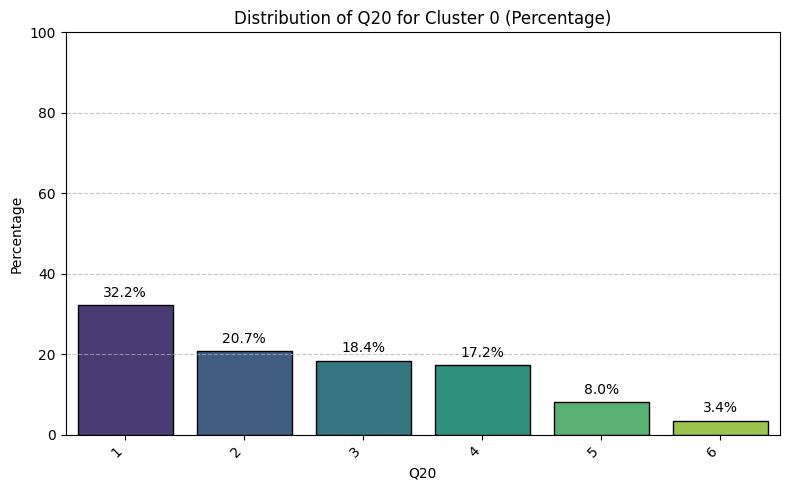

/tmp/ipykernel_7036/825235923.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


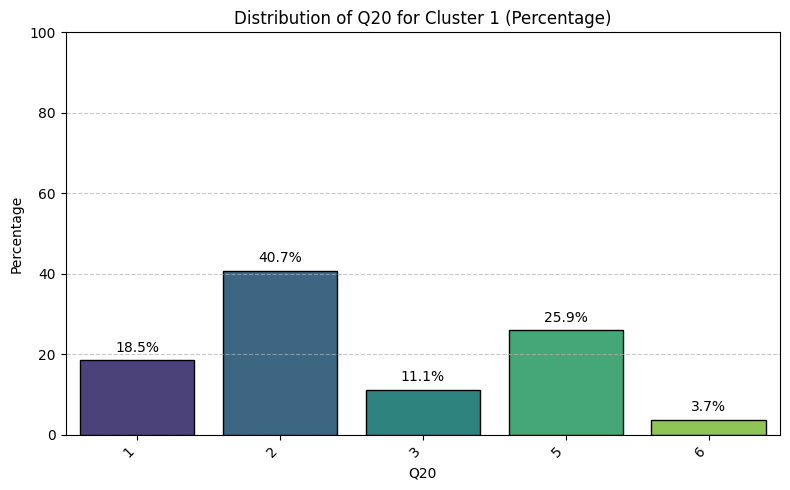

/tmp/ipykernel_7036/825235923.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


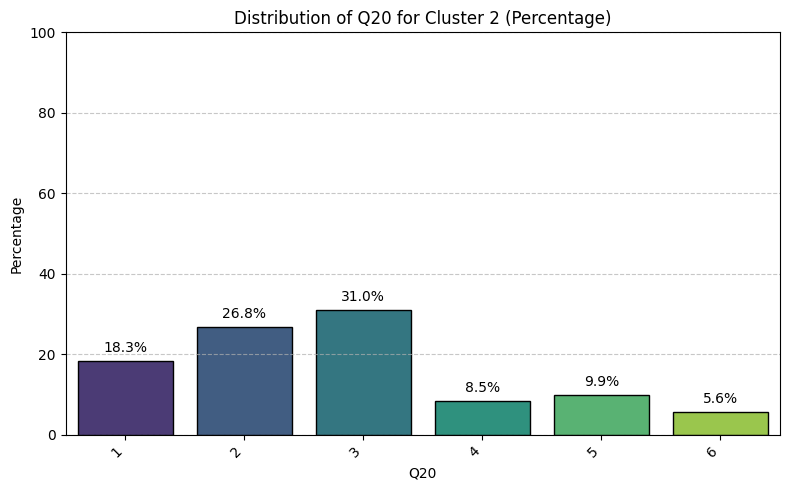

/tmp/ipykernel_7036/825235923.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


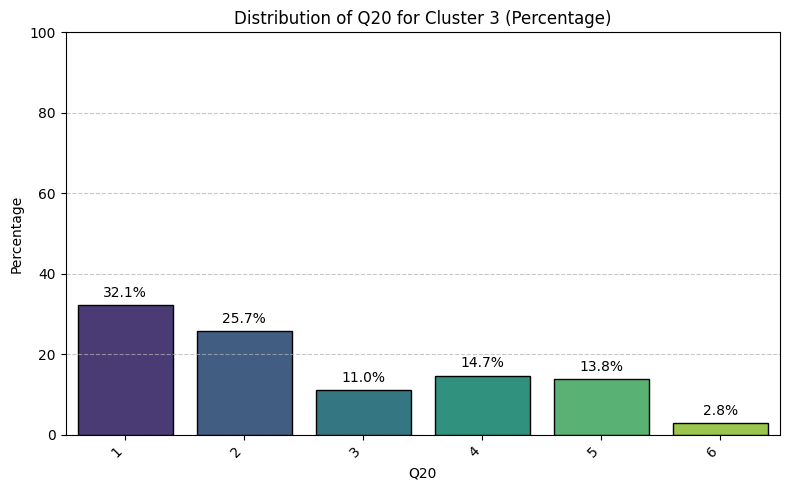


--- Distribution for Q21 across Clusters ---


/tmp/ipykernel_7036/825235923.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


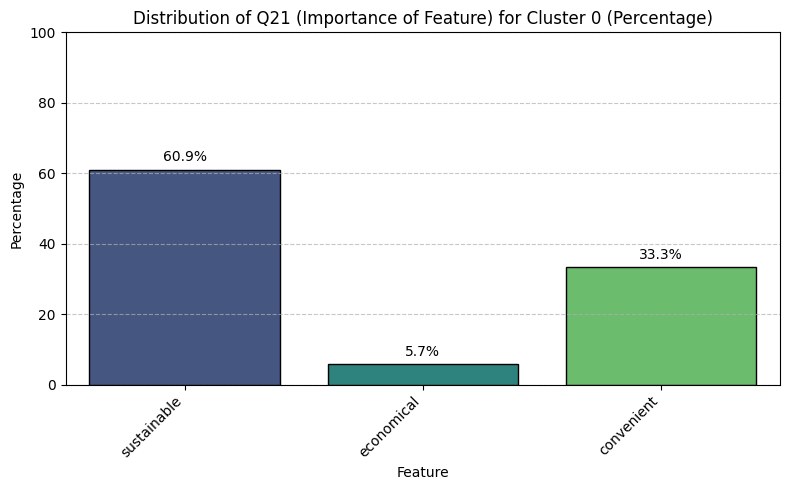

/tmp/ipykernel_7036/825235923.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


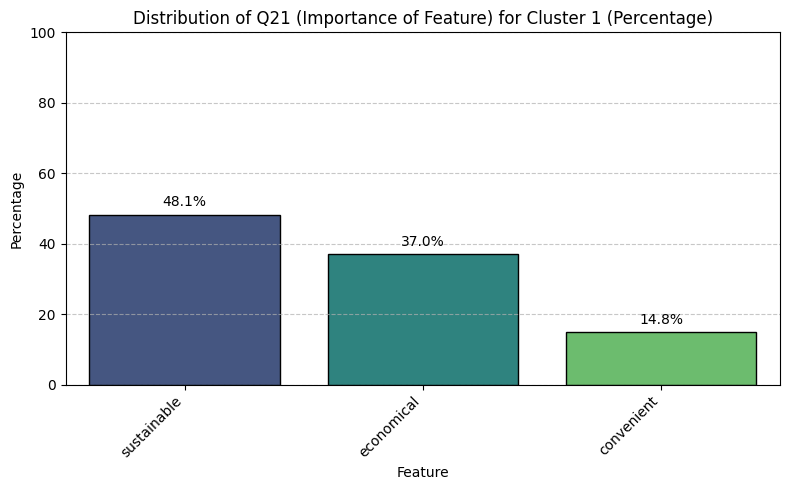

/tmp/ipykernel_7036/825235923.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


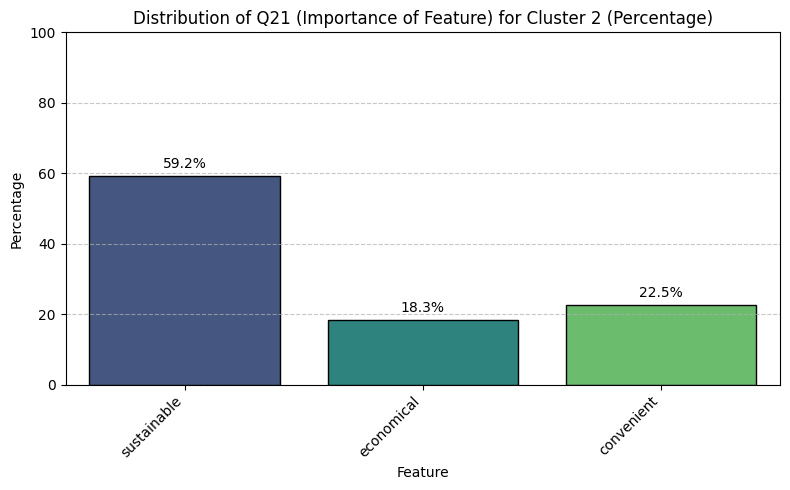

/tmp/ipykernel_7036/825235923.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


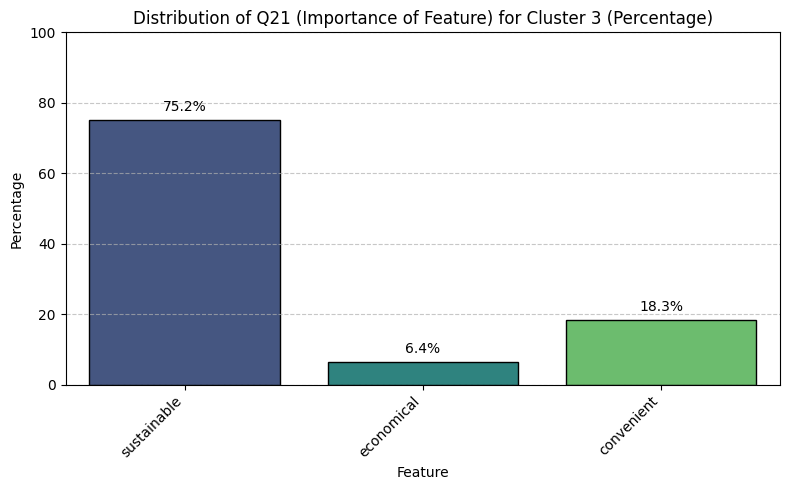


--- Distribution for Q23 across Clusters ---


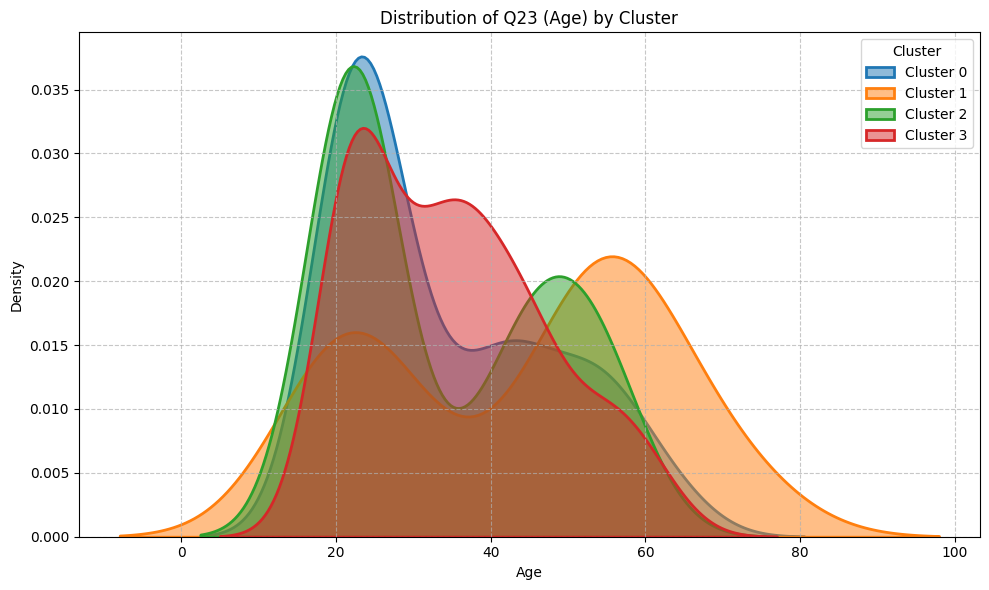


--- Distribution for Q24 across Clusters ---


/tmp/ipykernel_7036/825235923.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


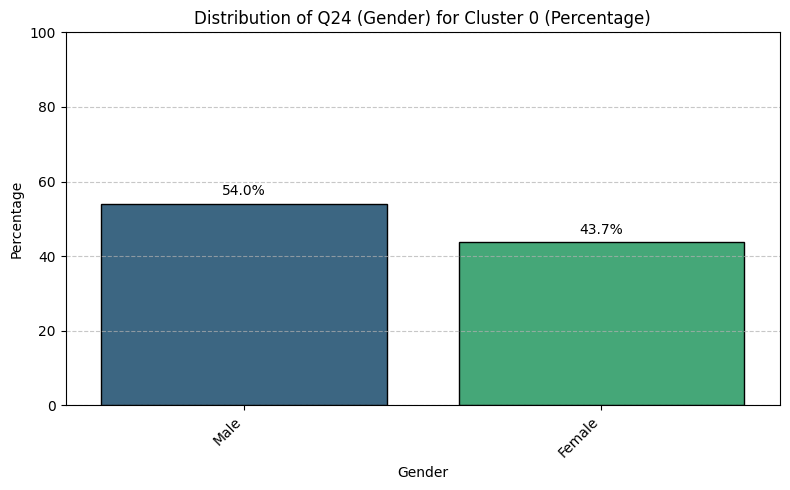

/tmp/ipykernel_7036/825235923.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


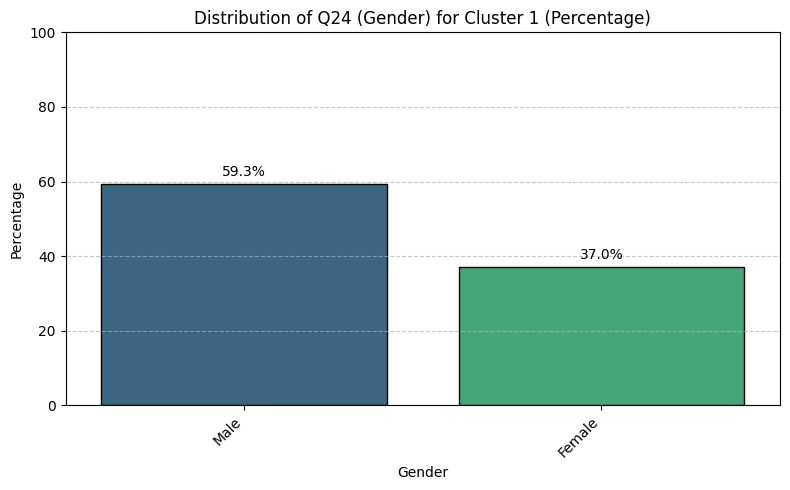

/tmp/ipykernel_7036/825235923.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


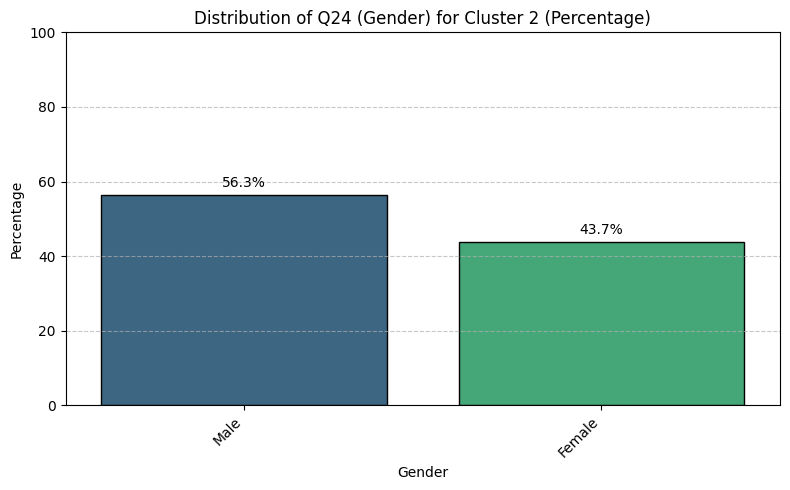

/tmp/ipykernel_7036/825235923.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


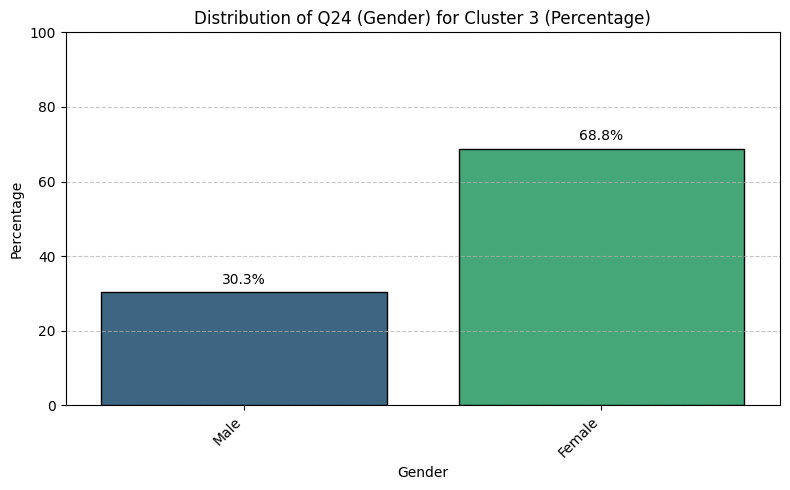

/tmp/ipykernel_7036/825235923.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(



--- Distribution for Q26 across Clusters ---


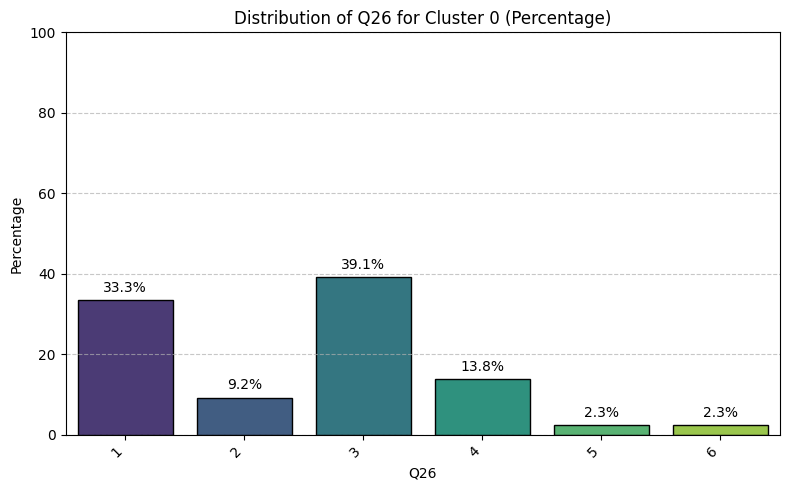

/tmp/ipykernel_7036/825235923.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


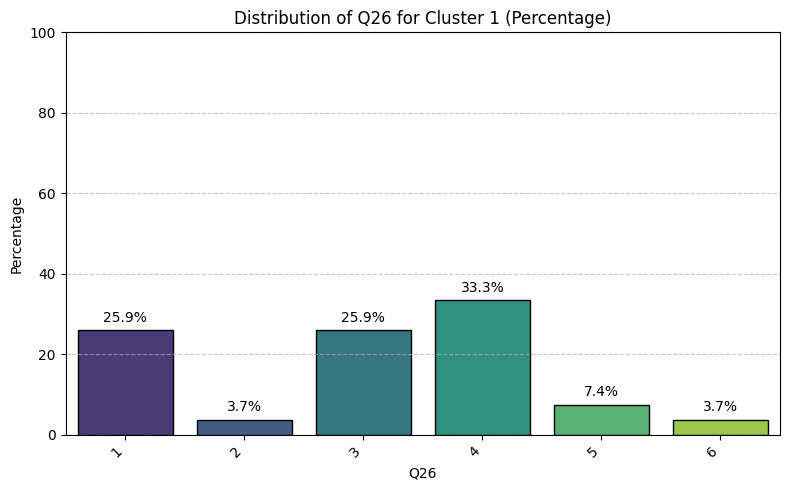

/tmp/ipykernel_7036/825235923.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


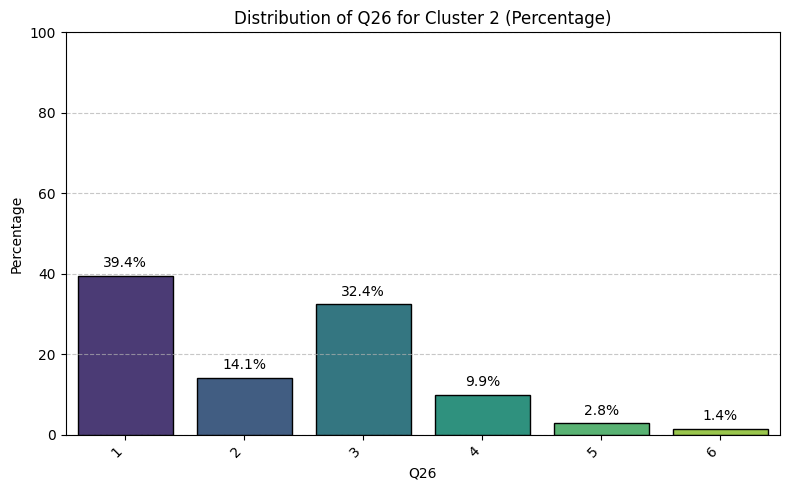

/tmp/ipykernel_7036/825235923.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


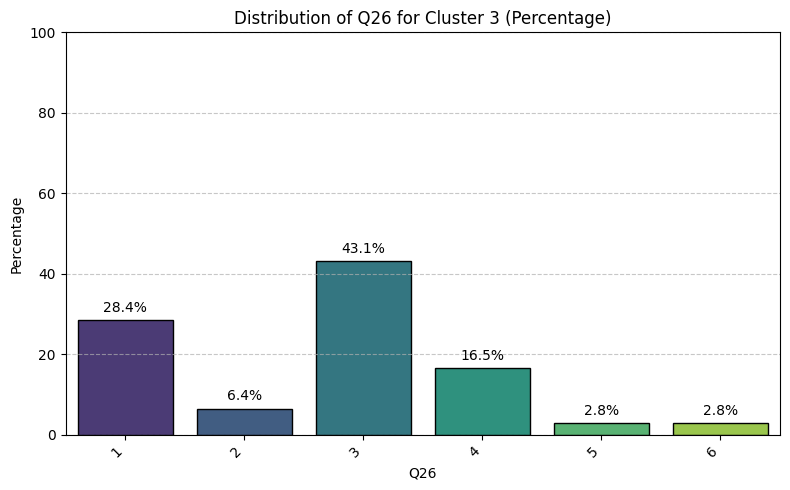

/tmp/ipykernel_7036/825235923.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(



--- Distribution for Q28 across Clusters ---


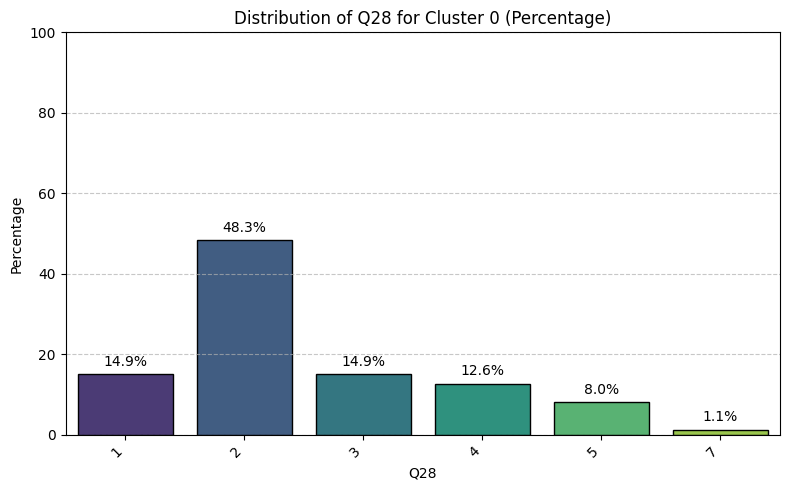

/tmp/ipykernel_7036/825235923.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


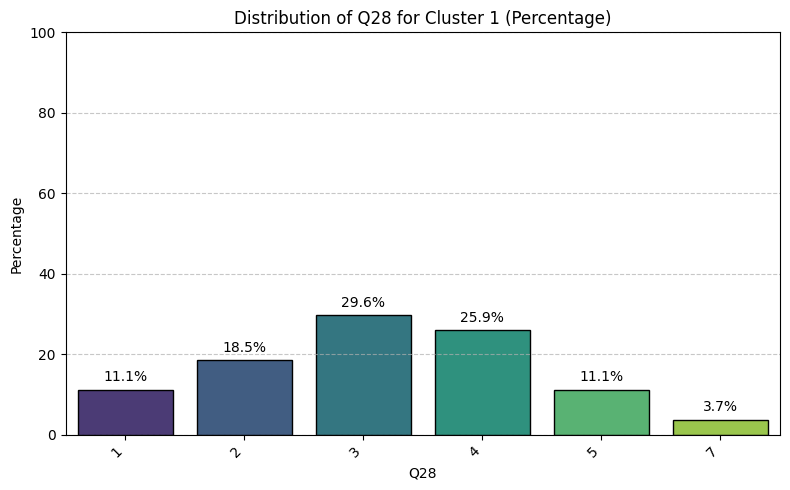

/tmp/ipykernel_7036/825235923.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


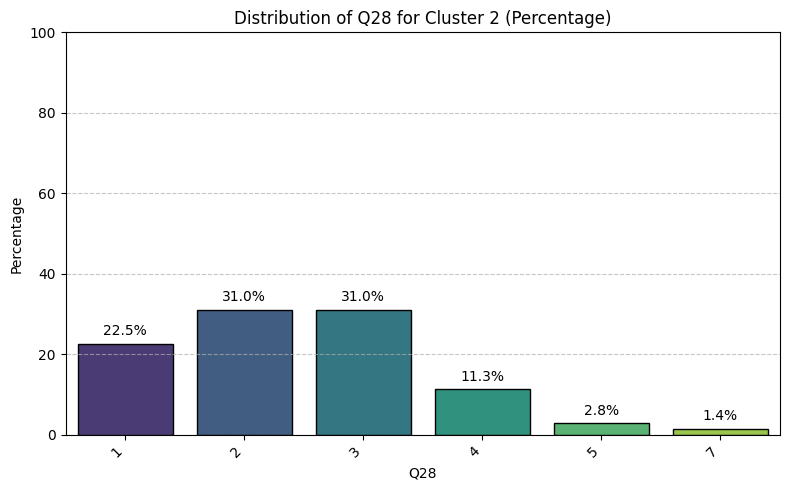

/tmp/ipykernel_7036/825235923.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


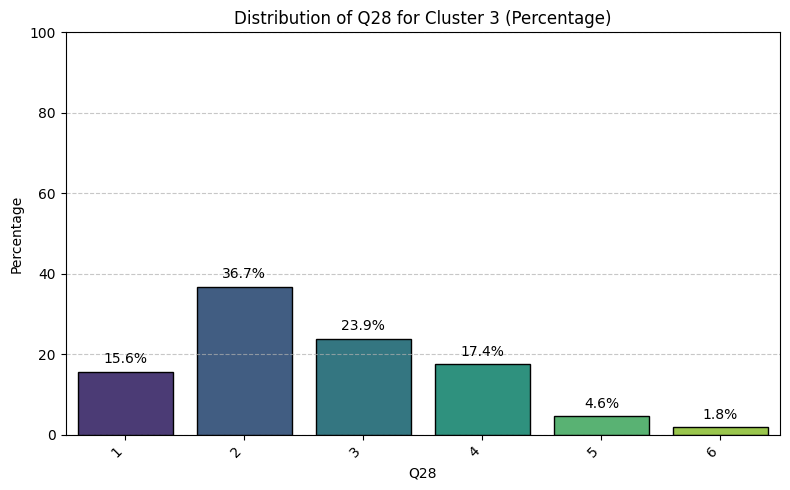

In [68]:
# Add cluster labels to the original DataFrame
# The 'kmeans_4_clusters.labels_' comes from the previously run K-Means model for 4 clusters.
# Ensure the index aligns between df and the cluster labels.
df_analysis = df.copy()
df_analysis['Cluster'] = kmeans_4_clusters.labels_

questions_to_analyze = ['Q20', 'Q21', 'Q23', 'Q24', 'Q26', 'Q28']

# Special mapping for Q21 (reusing the one from previous analysis)
q21_label_mapping = {1: 'sustainable', 3: 'convenient', 2: 'economical'}

# Label mapping for Q24 (Gender) - common assumption 1=Male, 2=Female
q24_label_mapping = {1: 'Male', 2: 'Female'} # Assuming these are the values for Q24

# Determine unique clusters present in the data
clusters = sorted(df_analysis['Cluster'].unique())

for question in questions_to_analyze:
    print(f"\n--- Distribution for {question} across Clusters ---")

    if question == 'Q23': # Age is a continuous numerical variable, use KDE plot
        plt.figure(figsize=(10, 6))
        for cluster_id in clusters:
            # Filter data for the current cluster and question, dropping NaN values
            cluster_data = df_analysis[df_analysis['Cluster'] == cluster_id][question].dropna()
            if not cluster_data.empty:
                sns.kdeplot(cluster_data, label=f'Cluster {cluster_id}', fill=True, alpha=0.5, linewidth=2)
        plt.title(f'Distribution of {question} (Age) by Cluster')
        plt.xlabel('Age')
        plt.ylabel('Density')
        plt.legend(title='Cluster')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

    else: # Categorical/Ordinal variables, use bar plots
        for cluster_id in clusters:
            plt.figure(figsize=(8, 5))
            # Create a copy to avoid SettingWithCopyWarning during modifications
            df_cluster = df_analysis[df_analysis['Cluster'] == cluster_id].copy()

            if not df_cluster.empty:
                # Calculate frequency and percentage for the current question within the cluster
                counts = df_cluster[question].value_counts().reset_index()
                counts.columns = ['Value', 'Frequency']
                counts['Percentage'] = (counts['Frequency'] / len(df_cluster)) * 100

                x_col = 'Value' # Default x-axis column for plotting
                title_suffix = '' # Suffix for the plot title
                x_label_text = question # Default text for x-axis label

                # Apply specific label mapping if the question is Q21 or Q24
                if question == 'Q21':
                    counts['Label'] = counts['Value'].map(q21_label_mapping)
                    x_col = 'Label'
                    title_suffix = ' (Importance of Feature)'
                    x_label_text = 'Feature'
                elif question == 'Q24':
                    counts['Label'] = counts['Value'].map(q24_label_mapping)
                    x_col = 'Label'
                    title_suffix = ' (Gender)'
                    x_label_text = 'Gender'

                # Sort the DataFrame by the original 'Value' column to ensure a consistent order for plotting
                counts = counts.sort_values(by='Value').reset_index(drop=True)

                ax = sns.barplot(
                    x=x_col,
                    y='Percentage',
                    data=counts,
                    palette='viridis', # Using a color palette
                    edgecolor='black'
                )
                plt.title(f'Distribution of {question}{title_suffix} for Cluster {cluster_id} (Percentage)')
                plt.xlabel(x_label_text)
                plt.ylabel('Percentage')
                plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
                plt.grid(axis='y', linestyle='--', alpha=0.7)

                # Add percentage labels on top of each bar
                for p in ax.patches:
                    ax.annotate(f'{p.get_height():.1f}%', # Format percentage to one decimal place
                                (p.get_x() + p.get_width() / 2., p.get_height()), # Position of the text
                                ha='center', va='center',
                                xytext=(0, 9), # Offset text slightly above the bar
                                textcoords='offset points')
                plt.ylim(0, 100) # Set y-axis maximum to 100% for percentages
                plt.tight_layout()
                plt.show()
            else:
                print(f"No data for {question} in Cluster {cluster_id}. Skipping plot.")